In [14]:
# Clustering di dataset echo e non-echo
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime
from sklearn.decomposition import PCA
import numpy as np



In [15]:
# Carica i dati
echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0)
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0)
real_echo_df = pd.read_csv("OLD/DataSet/3.outputs_Emotions/mean_vector_real_echo.csv", index_col=0)

echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(echo_df.columns)]
real_echo_df = real_echo_df[sorted(echo_df.columns)]

In [16]:
non_echo_df.index

Index(['output_AskReddit.csv', 'output_Bible.csv', 'output_books.csv',
       'output_changemyview.csv', 'output_CulinaryPlating.csv',
       'output_explainlikeimfive.csv', 'output_OutOfTheLoop.csv',
       'output_philosophy.csv', 'output_science.csv', 'output_shakespeare.csv',
       'output_skeptic.csv', 'output_sports.csv', 'output_todayilearned.csv',
       'output_TrueOffMyChest.csv', 'output_TrueReddit.csv'],
      dtype='object', name='file_name')

In [18]:
# Etichette per identificare la provenienza
echo_df['source'] = 'echo'
non_echo_df['source'] = 'non_echo'
real_echo_df['source'] = 'real_echo'
# Unisci i dataset
full_df = pd.concat([echo_df, non_echo_df, real_echo_df])

In [19]:
subreddit_name = list(full_df['source'].keys())
# Salva le etichette originali e poi rimuovi la colonna 'source' per il clustering
real_label = full_df['source']
data = full_df.drop(columns=['source','neutral'])

UMAP

In [20]:
# Standardizzazione
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Riduzione dimensionale per la visualizzazione
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(data_scaled)
real_label = full_df["source"]
numeric_real_label = [
    0 if x == "echo" else
    2 if x == "real_echo" else
    1
    for x in real_label
]

/Users/luigilomasto/.local/share/virtualenvs/EC2Vec-3fug5pHE/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardizzazione
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# PCA per visualizzazione (2D)
pca = PCA(n_components=2)
embedding = pca.fit_transform(data_scaled)

# Varianza spiegata (utile per capire quanta info stai mantenendo)
explained = pca.explained_variance_ratio_
print(f"Varianza spiegata: PC1={explained[0]:.3f}, PC2={explained[1]:.3f}, Totale={explained.sum():.3f}")

# Etichette come prima
real_label = full_df["source"]
numeric_real_label = [
    0 if x == "echo" else
    2 if x == "real_echo" else
    1
    for x in real_label
]


Varianza spiegata: PC1=0.153, PC2=0.113, Totale=0.266


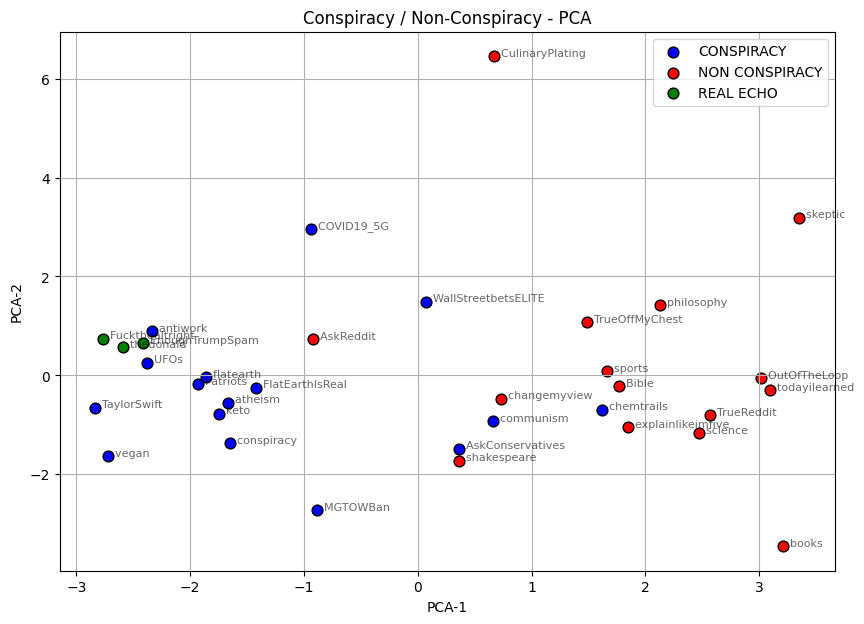

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Mappa: classe reale → marker e colore
marker_map = {0: 'o', 1: 's'}  # 0 = cerchio, 1 = quadrato
color_map = {0: 'blue', 1: 'red', 2: 'green'}  # 0 = blue, 1 = red

plt.figure(figsize=(10, 7))

# Visualizza solo i cluster reali
for real in np.unique(numeric_real_label):
    idx = np.where(numeric_real_label == real)[0]
    if real == 1:
        text_real = "NON CONSPIRACY"
    elif real == 2:
        text_real = "REAL ECHO"
    else:
        text_real = "CONSPIRACY"
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        c=color_map[real],
        marker='o',
        edgecolor='k',
        s=60,
        label=f"{text_real}"
    )

# Annotazione facoltativa dei nomi
for i, txt in enumerate(full_df.index):
    plt.annotate(
        txt.replace("reddit_filteredData_", "").replace(".csv", "").replace("output_", "  "),
        (embedding[i, 0], embedding[i, 1]),
        fontsize=8,
        alpha=0.6
    )

plt.title("Conspiracy / Non-Conspiracy - PCA")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.grid(True)
plt.legend()
plt.show()


In [26]:
full_df = pd.concat([echo_df, non_echo_df])
subreddit_name = list(full_df['source'].keys())
# Salva le etichette originali e poi rimuovi la colonna 'source' per il clustering
real_label = full_df['source']
data = full_df.drop(columns=['source','neutral'])#.fillna(0)

In [27]:
# Standardizzazione
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Riduzione dimensionale per la visualizzazione
#reducer = umap.UMAP(random_state=42)
#embedding = reducer.fit_transform(data_scaled)

# PCA per visualizzazione (2D)
pca = PCA(n_components=2)
embedding = pca.fit_transform(data_scaled)

# Clustering (KMeans come esempio)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(data_scaled)
real_label = full_df["source"]
print(clusters)

real_echo_df_scaled = scaler.transform(real_echo_df.drop(columns=['source','neutral']))
clusters_re = kmeans.predict(real_echo_df_scaled)
print(clusters_re)

#numeric_real_label = [0 if x == "echo" else 1 for x in real_label]

numeric_real_label = [
    0 if x == "echo" else
    2 if x == "real_echo" else
    1
    for x in real_label
]

for i in range(len(clusters)):
    print(str(subreddit_name[i])+" -- Real: "+str(numeric_real_label[i])+" -- Predicted: "+str(clusters[i]))

[0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0]
output_antiwork.csv -- Real: 0 -- Predicted: 0
output_AskConservatives.csv -- Real: 0 -- Predicted: 0
output_atheism.csv -- Real: 0 -- Predicted: 0
output_chemtrails.csv -- Real: 0 -- Predicted: 1
output_communism.csv -- Real: 0 -- Predicted: 1
output_conspiracy.csv -- Real: 0 -- Predicted: 0
output_COVID19_5G.csv -- Real: 0 -- Predicted: 0
output_flatearth.csv -- Real: 0 -- Predicted: 0
output_FlatEarthIsReal.csv -- Real: 0 -- Predicted: 0
output_keto.csv -- Real: 0 -- Predicted: 0
output_MGTOWBan.csv -- Real: 0 -- Predicted: 0
output_Patriots.csv -- Real: 0 -- Predicted: 0
output_TaylorSwift.csv -- Real: 0 -- Predicted: 0
output_UFOs.csv -- Real: 0 -- Predicted: 0
output_vegan.csv -- Real: 0 -- Predicted: 0
output_WallStreetbetsELITE.csv -- Real: 0 -- Predicted: 1
output_AskReddit.csv -- Real: 1 -- Predicted: 0
output_Bible.csv -- Real: 1 -- Predicted: 1
output_books.csv -- Real: 1 -- Predicted: 1
output_changemy

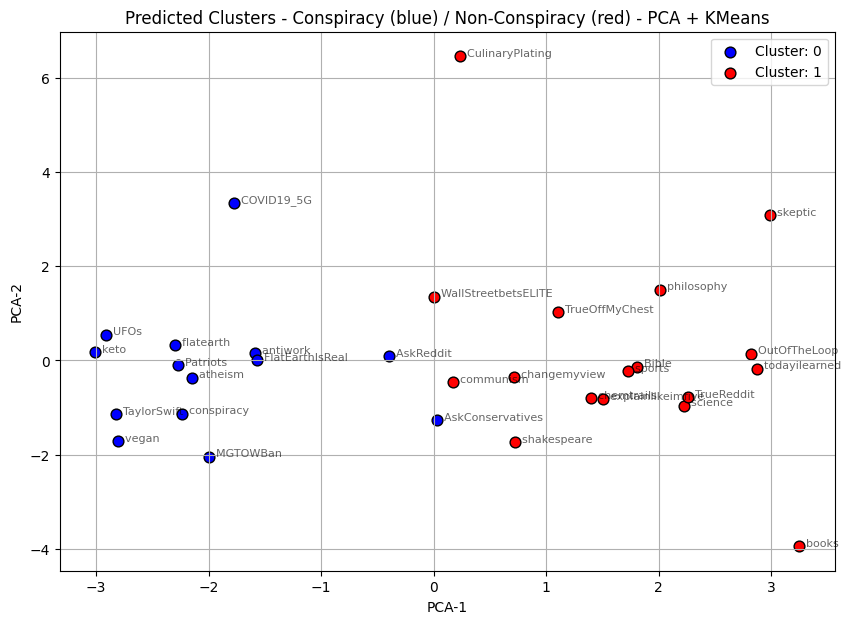

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Mappa: classe predetta → marker e colore
marker_map = {0: 'o', 1: 's'}  # opzionale: puoi usare lo stesso marker per tutti se non ti serve
color_map = {0: 'blue', 1: 'red'}

plt.figure(figsize=(10, 7))

# Visualizza solo i cluster predetti
for pred in np.unique(clusters):
    idx = np.where(clusters == pred)[0]
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        c=color_map[pred],
        marker='o',  # oppure marker_map[pred] se vuoi marker diversi
        edgecolor='k',
        s=60,
        label=f"Cluster: {pred}"
    )

# Annotazione facoltativa dei nomi
for i, txt in enumerate(full_df.index):
    plt.annotate(
        txt.replace("reddit_filteredData_", "").replace(".csv", "").replace("output_", "  "),
        (embedding[i, 0], embedding[i, 1]),
        fontsize=8,
        alpha=0.6
    )

plt.title("Predicted Clusters - Conspiracy (blue) / Non-Conspiracy (red) - PCA + KMeans")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.grid(True)
plt.legend()
plt.show()


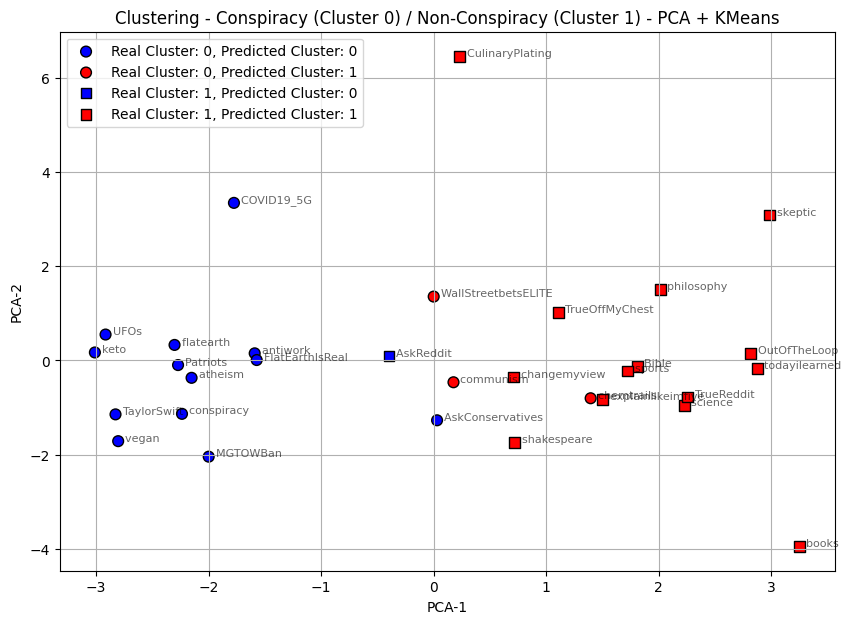

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Supponiamo che tu abbia questi array:
# embedding: (n, 2) -> le coordinate UMAP
# predicted_label: array con le classi predette (0 o 1)
# real_label: array con le classi reali (0 o 1)
# full_df.index: gli identificatori dei punti

# Mappa: classe reale → marker
marker_map = {0: 'o', 1: 's'}  # 0 = cerchio, 1 = quadrato

# Mappa: classe predetta → colore
color_map = {0: 'blue', 1: 'red'}

plt.figure(figsize=(10, 7))

for real in np.unique(numeric_real_label):
    for pred in np.unique(clusters):
        idx = np.where((numeric_real_label == real) & (clusters == pred))[0]
        plt.scatter(
            embedding[idx, 0],
            embedding[idx, 1],
            c=[color_map[p] for p in clusters[idx]],
            marker=marker_map[real],
            edgecolor='k',
            s=60,
            label=f"Real Cluster: {real}, Predicted Cluster: {pred}"
        )

# Annotazione facoltativa dei nomi
for i, txt in enumerate(full_df.index):
    plt.annotate(
        txt.replace("reddit_filteredData_", "").replace(".csv", "").replace("output_", "  "),
        (embedding[i, 0], embedding[i, 1]),
        fontsize=8,
        alpha=0.6
    )

plt.title("Clustering - Conspiracy (Cluster 0) / Non-Conspiracy (Cluster 1) - PCA + KMeans")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.grid(True)
plt.legend()
plt.show()

LOGISTIC REGRESSION Cross Validation K-fold leave one out

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import classification_report, accuracy_score

# Carica i dati
echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0).drop(columns=['neutral'])
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0).drop(columns=['neutral'])

# Ordina le colonne
echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(non_echo_df.columns)]

# Aggiungi etichette
echo_df["label"] = 1
non_echo_df["label"] = 0

# Unisci i dati
df = pd.concat([echo_df, non_echo_df])
X = df.drop(columns=["label"]).values
y = df["label"].values

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(pred[0])

# Valutazione finale
print("Accuracy (LOOCV):", accuracy_score(y_true, y_pred))
print("\nClassification Report (LOOCV):\n", classification_report(y_true, y_pred))


Accuracy (LOOCV): 0.9032258064516129

Classification Report (LOOCV):
               precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       0.88      0.94      0.91        16

    accuracy                           0.90        31
   macro avg       0.91      0.90      0.90        31
weighted avg       0.90      0.90      0.90        31



Stratified 80/20 -> test C0: 3/16, test C1: 3/15 (tot test=6)
Stratified splits evaluated: 1000
Overall — Acc(mean)=0.874, Prec(macro)=0.904, Rec(macro)=0.874, F1(macro)=0.870
C0 — Acc=0.830, Prec=0.937, Rec=0.830, F1=0.863
C1 — Acc=0.917, Prec=0.871, Rec=0.917, F1=0.877


/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_82491/3074822557.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],


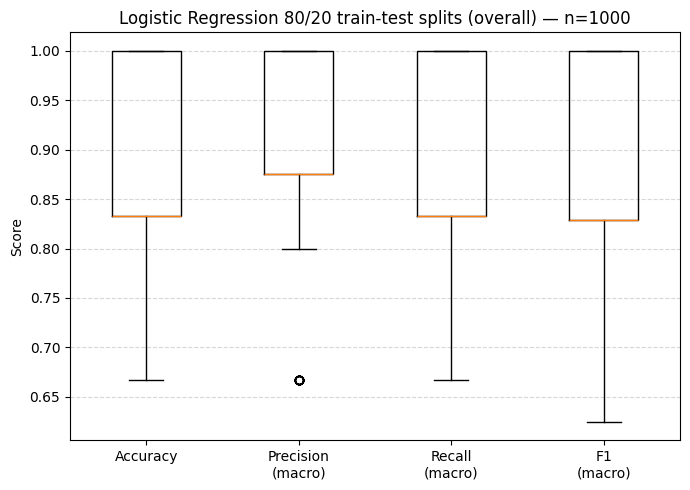

/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_82491/3074822557.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


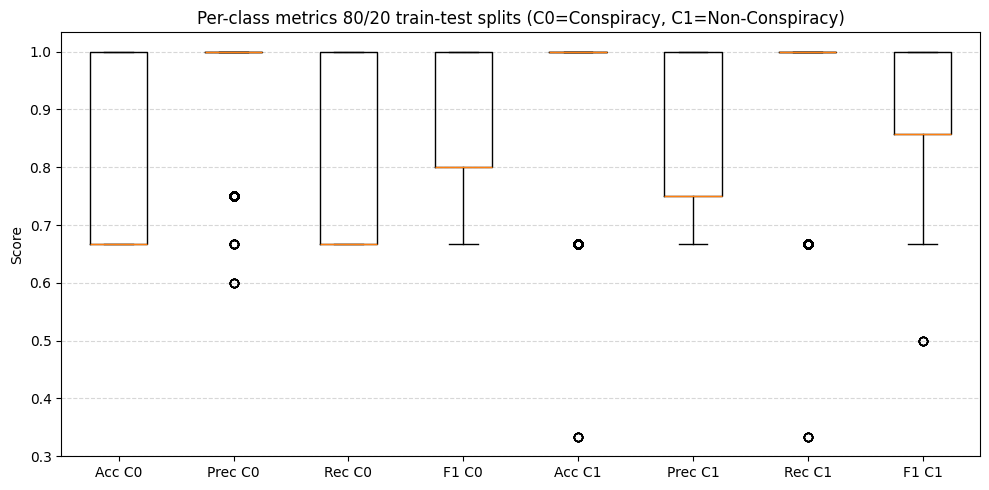

In [13]:
import pandas as pd
import numpy as np
import itertools, random
from math import floor
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support
)

# ---------------- Config ----------------
ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv"
NON_ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv"
REMOVE_COL = "neutral"
TEST_RATIO = 0.20
MAX_SPLITS = 1000          # None per TUTTE le combinazioni (potrebbero essere tantissime)
RANDOM_SEED = 42

# ---------------- Load & prep ----------------
echo_df = pd.read_csv(ECHO_PATH, index_col=0)
non_echo_df = pd.read_csv(NON_ECHO_PATH, index_col=0)

for df_ in (echo_df, non_echo_df):
    if REMOVE_COL in df_.columns:
        df_.drop(columns=[REMOVE_COL], inplace=True)

cols_sorted = sorted(set(echo_df.columns) & set(non_echo_df.columns))
echo_df = echo_df[cols_sorted].copy()
non_echo_df = non_echo_df[cols_sorted].copy()

echo_df["label"] = 0  # C0 = CONSPIRACY
non_echo_df["label"] = 1  # C1 = NON_CONSPIRACY

df = pd.concat([echo_df, non_echo_df], axis=0)
X = df.drop(columns=["label"]).to_numpy(dtype=float)
y = df["label"].to_numpy()

# ---------------- Indici per classe ----------------
idx_c0 = np.where(y == 0)[0]
idx_c1 = np.where(y == 1)[0]
n0, n1 = len(idx_c0), len(idx_c1)

t0 = max(1, int(round(TEST_RATIO * n0)))
t1 = max(1, int(round(TEST_RATIO * n1)))
t0 = min(t0, n0 - 1)
t1 = min(t1, n1 - 1)

print(f"Stratified 80/20 -> test C0: {t0}/{n0}, test C1: {t1}/{n1} (tot test={t0+t1})")

comb_c0 = list(itertools.combinations(idx_c0, t0))
comb_c1 = list(itertools.combinations(idx_c1, t1))

random.Random(RANDOM_SEED).shuffle(comb_c0)
random.Random(RANDOM_SEED + 1).shuffle(comb_c1)

prod_iter = itertools.product(comb_c0, comb_c1)
if MAX_SPLITS is not None:
    prod_iter = itertools.islice(prod_iter, MAX_SPLITS)

# ---------------- Modello (Logistic + scaling) ----------------
model_tpl = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=RANDOM_SEED, max_iter=2000)
)

# ---------------- Metriche ----------------
acc_list = []
prec_macro_list, rec_macro_list, f1_macro_list = [], [], []

acc_c0_list, acc_c1_list = [], []
prec_c0_list, prec_c1_list = [], []
rec_c0_list, rec_c1_list = [], []
f1_c0_list, f1_c1_list = [], []

n_splits = 0
for test_c0, test_c1 in prod_iter:
    n_splits += 1
    test_idx = np.array(list(test_c0) + list(test_c1))
    train_mask = np.ones(len(y), dtype=bool)
    train_mask[test_idx] = False

    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]

    model = model_tpl
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # global (macro)
    acc_list.append(accuracy_score(y_test, y_pred))
    prec_macro_list.append(precision_score(y_test, y_pred, average="macro", zero_division=0))
    rec_macro_list.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
    f1_macro_list.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

    # per-class (labels=[0,1] -> C0, C1)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1], zero_division=0)
    prec_c0_list.append(p[0]); prec_c1_list.append(p[1])
    rec_c0_list.append(r[0]);  rec_c1_list.append(r[1])
    f1_c0_list.append(f[0]);   f1_c1_list.append(f[1])
    # "accuracy per classe" = recall della classe
    acc_c0_list.append(r[0]);  acc_c1_list.append(r[1])

print(f"Stratified splits evaluated: {n_splits}")
print(f"Overall — Acc(mean)={np.mean(acc_list):.3f}, Prec(macro)={np.mean(prec_macro_list):.3f}, "
      f"Rec(macro)={np.mean(rec_macro_list):.3f}, F1(macro)={np.mean(f1_macro_list):.3f}")
print(f"C0 — Acc={np.mean(acc_c0_list):.3f}, Prec={np.mean(prec_c0_list):.3f}, "
      f"Rec={np.mean(rec_c0_list):.3f}, F1={np.mean(f1_c0_list):.3f}")
print(f"C1 — Acc={np.mean(acc_c1_list):.3f}, Prec={np.mean(prec_c1_list):.3f}, "
      f"Rec={np.mean(rec_c1_list):.3f}, F1={np.mean(f1_c1_list):.3f}")

# ---------------- Boxplots ----------------
plt.figure(figsize=(7,5))
plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],
            labels=["Accuracy", "Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"])
plt.ylabel("Score")
plt.title(f"Logistic Regression 80/20 train-test splits (overall) — n={n_splits}")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.boxplot([
    acc_c0_list, prec_c0_list, rec_c0_list, f1_c0_list,
    acc_c1_list, prec_c1_list, rec_c1_list, f1_c1_list
], labels=[
    "Acc C0", "Prec C0", "Rec C0", "F1 C0",
    "Acc C1", "Prec C1", "Rec C1", "F1 C1"
])
plt.ylabel("Score")
plt.title("Per-class metrics 80/20 train-test splits (C0=Conspiracy, C1=Non-Conspiracy)")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


MLP Corsso Validation leaveoneout

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Carica i dati
echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0).drop(columns=['neutral'])
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0).drop(columns=['neutral'])

# Ordina le colonne
echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(non_echo_df.columns)]

# Aggiungi etichette
echo_df["label"] = 1
non_echo_df["label"] = 0

# Unisci i dati
df = pd.concat([echo_df, non_echo_df])
X = df.drop(columns=["label"]).values
y = df["label"].values

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # MLP Classifier
    model = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(pred[0])

# Valutazione
print("Accuracy (LOOCV - MLP):", accuracy_score(y_true, y_pred))
print("\nClassification Report (LOOCV - MLP):\n", classification_report(y_true, y_pred))


Accuracy (LOOCV - MLP): 0.9032258064516129

Classification Report (LOOCV - MLP):
               precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.93      0.88      0.90        16

    accuracy                           0.90        31
   macro avg       0.90      0.90      0.90        31
weighted avg       0.91      0.90      0.90        31



Stratified 80/20 -> test C0: 3/16, test C1: 3/15 (tot test=6)
Stratified splits evaluated: 1000
Overall — Acc(mean)=0.785, Prec(macro)=0.811, Rec(macro)=0.785, F1(macro)=0.782
C0 — Acc=0.703, Prec=0.876, Rec=0.703, F1=0.769
C1 — Acc=0.867, Prec=0.746, Rec=0.867, F1=0.794


/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_82491/1700274325.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],


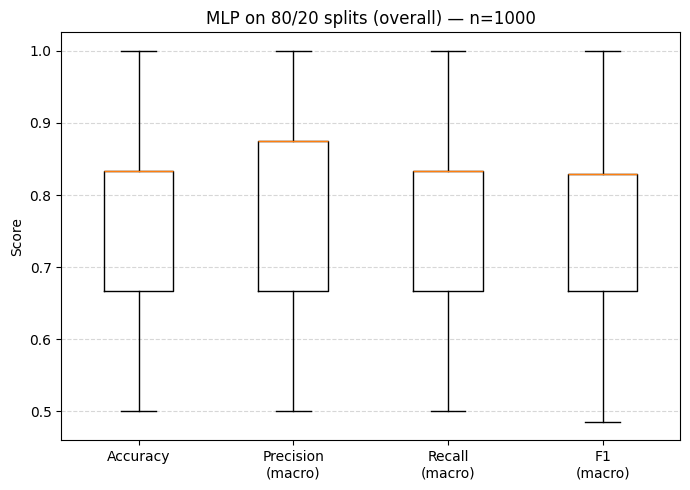

/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_82491/1700274325.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


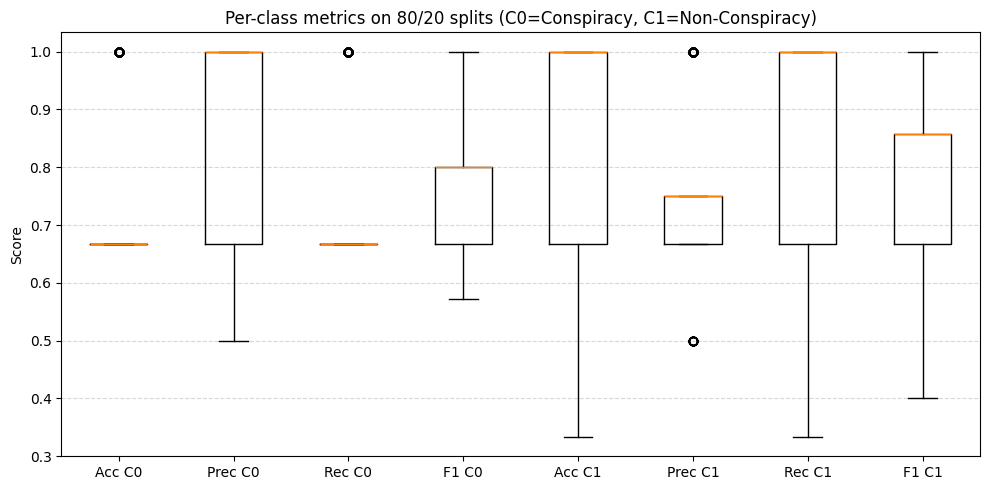

In [17]:
import pandas as pd
import numpy as np
import itertools, random
from math import floor
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support
)

# ---------------- Config ----------------
ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv"
NON_ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv"
REMOVE_COL = "neutral"
TEST_RATIO = 0.20
MAX_SPLITS = 1000          # None per tutte le combinazioni (può essere enorme)
RANDOM_SEED = 42

# ---------------- Load & prep ----------------
echo_df = pd.read_csv(ECHO_PATH, index_col=0)
non_echo_df = pd.read_csv(NON_ECHO_PATH, index_col=0)

for df_ in (echo_df, non_echo_df):
    if REMOVE_COL in df_.columns:
        df_.drop(columns=[REMOVE_COL], inplace=True)

cols_sorted = sorted(set(echo_df.columns) & set(non_echo_df.columns))
echo_df = echo_df[cols_sorted].copy()
non_echo_df = non_echo_df[cols_sorted].copy()

echo_df["label"] = 0  # C0 = CONSPIRACY
non_echo_df["label"] = 1  # C1 = NON_CONSPIRACY

df = pd.concat([echo_df, non_echo_df], axis=0)
X = df.drop(columns=["label"]).to_numpy(dtype=float)
y = df["label"].to_numpy()

# ---------------- Indici per classe ----------------
idx_c0 = np.where(y == 0)[0]
idx_c1 = np.where(y == 1)[0]
n0, n1 = len(idx_c0), len(idx_c1)

# conteggi test set per ciascuna classe (almeno 1, non più della classe)
t0 = max(1, int(round(TEST_RATIO * n0)))
t1 = max(1, int(round(TEST_RATIO * n1)))
t0 = min(t0, n0 - 1)
t1 = min(t1, n1 - 1)

print(f"Stratified 80/20 -> test C0: {t0}/{n0}, test C1: {t1}/{n1} (tot test={t0+t1})")

# combinazioni per classe
comb_c0 = list(itertools.combinations(idx_c0, t0))
comb_c1 = list(itertools.combinations(idx_c1, t1))

# mischiamo l'ordine per campionare quando limitiamo
random.Random(RANDOM_SEED).shuffle(comb_c0)
random.Random(RANDOM_SEED + 1).shuffle(comb_c1)

# prodotto cartesiano (tutte le combinazioni stratificate)
prod_iter = itertools.product(comb_c0, comb_c1)

# opzionale: limita numero di split totali
if MAX_SPLITS is not None:
    prod_iter = itertools.islice(prod_iter, MAX_SPLITS)

model_tpl = make_pipeline(StandardScaler(),MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', random_state=42, max_iter=1000))

# ---------------- Metriche ----------------
acc_list = []
prec_macro_list, rec_macro_list, f1_macro_list = [], [], []

# per-class (C0=Conspiracy, C1=Non-Conspiracy)
acc_c0_list, acc_c1_list = [], []
prec_c0_list, prec_c1_list = [], []
rec_c0_list, rec_c1_list = [], []
f1_c0_list, f1_c1_list = [], []

n_splits = 0
for test_c0, test_c1 in prod_iter:
    n_splits += 1
    test_idx = np.array(list(test_c0) + list(test_c1))
    train_mask = np.ones(len(y), dtype=bool)
    train_mask[test_idx] = False

    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]

    model = model_tpl  # nuova istanza non necessaria in pipeline standard
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # globali (macro)
    acc_list.append(accuracy_score(y_test, y_pred))
    prec_macro_list.append(precision_score(y_test, y_pred, average="macro", zero_division=0))
    rec_macro_list.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
    f1_macro_list.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

    # per-classe
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1], zero_division=0)
    prec_c0_list.append(p[0]); prec_c1_list.append(p[1])
    rec_c0_list.append(r[0]);  rec_c1_list.append(r[1])
    f1_c0_list.append(f[0]);   f1_c1_list.append(f[1])
    # "accuracy per classe" = recall della classe
    acc_c0_list.append(r[0]);  acc_c1_list.append(r[1])

print(f"Stratified splits evaluated: {n_splits}")
print(f"Overall — Acc(mean)={np.mean(acc_list):.3f}, Prec(macro)={np.mean(prec_macro_list):.3f}, "
      f"Rec(macro)={np.mean(rec_macro_list):.3f}, F1(macro)={np.mean(f1_macro_list):.3f}")
print(f"C0 — Acc={np.mean(acc_c0_list):.3f}, Prec={np.mean(prec_c0_list):.3f}, "
      f"Rec={np.mean(rec_c0_list):.3f}, F1={np.mean(f1_c0_list):.3f}")
print(f"C1 — Acc={np.mean(acc_c1_list):.3f}, Prec={np.mean(prec_c1_list):.3f}, "
      f"Rec={np.mean(rec_c1_list):.3f}, F1={np.mean(f1_c1_list):.3f}")

# ---------------- Boxplots ----------------
plt.figure(figsize=(7,5))
plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],
            labels=["Accuracy", "Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"])
plt.ylabel("Score")
plt.title(f"{"mlp".upper()} on 80/20 splits (overall) — n={n_splits}")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.boxplot([
    acc_c0_list, prec_c0_list, rec_c0_list, f1_c0_list,
    acc_c1_list, prec_c1_list, rec_c1_list, f1_c1_list
], labels=[
    "Acc C0", "Prec C0", "Rec C0", "F1 C0",
    "Acc C1", "Prec C1", "Rec C1", "F1 C1"
])
plt.ylabel("Score")
plt.title("Per-class metrics on 80/20 splits (C0=Conspiracy, C1=Non-Conspiracy)")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Logistic and MLP con tutto il dataset per classificare REC

In [18]:
# Logistic Regression per classificazione echo vs non_echo
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Carica i dati
echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0).drop(columns=['neutral'])
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0).drop(columns=['neutral'])


# Ordina le colonne in entrambi i DataFrame
echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(non_echo_df.columns)]


# Aggiungi etichette: 1 = echo, 0 = non_echo
echo_df["label"] = 0
non_echo_df["label"] = 1

# Unisci i dati
df = pd.concat([echo_df, non_echo_df])
X = df.drop(columns=["label"])
y = df["label"]

# Divisione in train/test

# Modello di regressione logistica
model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X, y)

real_echo_df = pd.read_csv("OLD/DataSet/3.outputs_Emotions/mean_vector_real_echo.csv", index_col=0).drop(columns=['neutral']).fillna(0)
real_echo_df = real_echo_df[sorted(real_echo_df.columns)]

y_pred = model.predict_proba(real_echo_df)
print(y_pred)


[[0.53501326 0.46498674]
 [0.53294557 0.46705443]
 [0.53380592 0.46619408]]


Multi Layer Perceptron

In [19]:
import pandas as pd
from sklearn.neural_network import MLPClassifier

# MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', random_state=42, max_iter=1000)
mlp.fit(X, y)

real_echo_df = pd.read_csv("OLD/DataSet/3.outputs_Emotions/mean_vector_real_echo.csv", index_col=0).drop(columns=['neutral']).fillna(0)
real_echo_df = real_echo_df[sorted(real_echo_df.columns)]

y_pred = mlp.predict_proba(real_echo_df)
print(y_pred)


[[0.66120544 0.33879456]
 [0.8187138  0.1812862 ]
 [0.77913382 0.22086618]]


array([0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1])

[[0.62148437 0.37851563]
 [0.2238997  0.7761003 ]
 [0.27894306 0.72105694]]


<h1> LDA </h1>

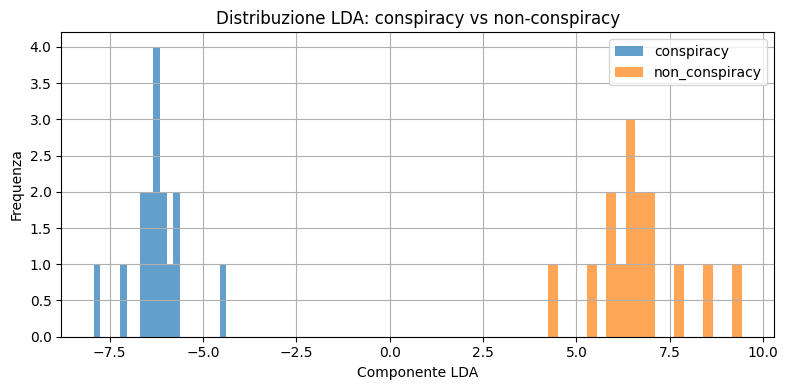

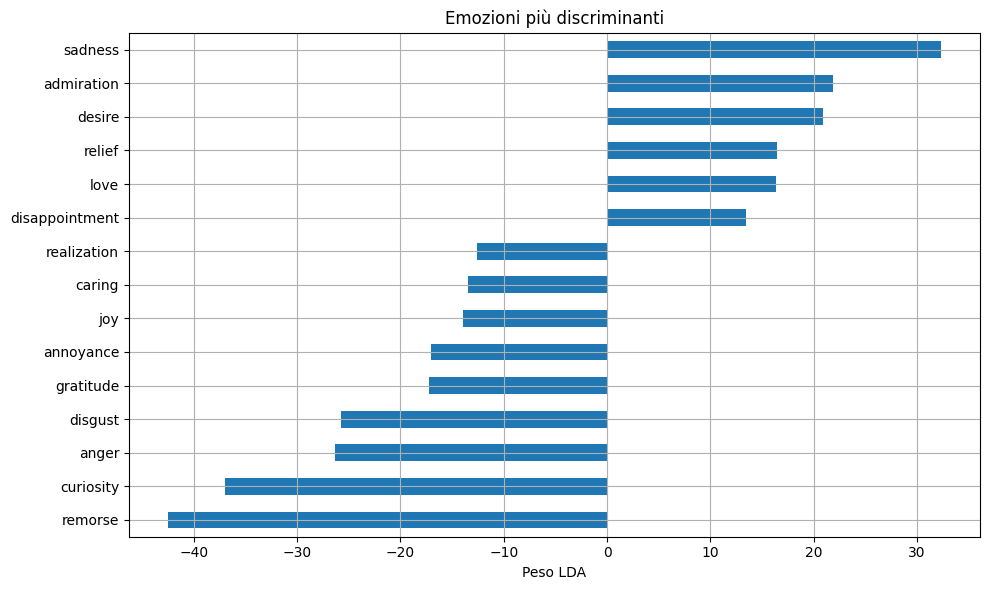

In [36]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt

echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv")
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv")

# Aggiungi le etichette
echo_df["label"] = "conspiracy"
non_echo_df["label"] = "non_conspiracy"


# Unisci i dati
df = pd.concat([echo_df, non_echo_df], ignore_index=True)


# Seleziona le colonne emotive (escludi 'file_name' e 'label')
X = df.drop(columns=["file_name", "label", "neutral"])
y = df["label"]

# Standardizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applica LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# Visualizza la distribuzione
plt.figure(figsize=(8, 4))
plt.hist(X_lda[y == "conspiracy"], bins=20, alpha=0.7, label="conspiracy")
plt.hist(X_lda[y == "non_conspiracy"], bins=20, alpha=0.7, label="non_conspiracy")
plt.title("Distribuzione LDA: conspiracy vs non-conspiracy")
plt.xlabel("Componente LDA")
plt.ylabel("Frequenza")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# Coefficienti delle emozioni nella discriminazione
lda_coefficients = pd.Series(lda.coef_[0], index=X.columns)
lda_coefficients_sorted = lda_coefficients.abs().sort_values(ascending=False)

# Visualizza le emozioni più importanti
top_emotions = lda_coefficients_sorted.head(15).index
lda_coefficients[top_emotions].sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Emozioni più discriminanti")
plt.xlabel("Peso LDA")
plt.tight_layout()
plt.grid(True)
plt.show()


In [8]:
def dataset_cleaner(controversial, non_controversial, controversial_groups_to_use, non_controversial_groups_to_use):
    if len(controversial_groups_to_use) != 0:
        controversial = controversial[controversial["file_name"].isin(controversial_groups_to_use)]

    if len(non_controversial_groups_to_use) != 0:
        non_controversial = non_controversial[non_controversial["file_name"].isin(non_controversial_groups_to_use)]

    controversial = controversial.drop(columns = ["file_name","neutral"])
    non_controversial = non_controversial.drop(columns = ["file_name","neutral"])
    return controversial, non_controversial

def evaluate_best_emotions(controversial, non_controversial, num_emotions):
    combo = pd.concat([controversial,non_controversial])
    return list(combo.var().sort_values(ascending=False).index[0:num_emotions])

def confusion_matrix_builder(controversial, non_controversial, emotions_to_use):
    controversial = controversial[emotions_to_use]
    non_controversial = non_controversial[emotions_to_use]
    controversial_groups_cs = cosine_similarity(controversial, controversial)
    controversial_non_controversial_groups_cs = cosine_similarity(controversial,non_controversial)
    non_controversial_groups_cs = cosine_similarity(non_controversial, non_controversial)
    return controversial_groups_cs, controversial_non_controversial_groups_cs, non_controversial_groups_cs

def plot_matrix(groups, name_to_use_x, name_to_use_y, type_of_groups, num_emotions):
    fig, ax =  plt.subplots()
    ax.matshow(groups)
    ax.set_xticklabels(['']+name_to_use_x,rotation=90, fontsize=12)
    ax.set_yticklabels(['']+name_to_use_y,fontsize=12)

    for (i, j), z in np.ndenumerate(groups):
        ax.text(j, i, '{:0.3f}'.format(z), ha='center', va='center', fontsize=12)

    plt.set_cmap("Blues")
    plt.show()
    fig.savefig("plots/matrix_cosine_similarity_" + type_of_groups + "_" + str(num_emotions)+".png", bbox_inches='tight')

def avarage_confusion_matrix_similarity(matrix, is_square = False):
    num_i, num_j = matrix.shape
    counter = 0
    somma = 0
    for i in range(0, num_i):
        for j in range(0, num_j):
            if is_square and i != j:
                somma += matrix[i, j]
                counter += 1
            elif not is_square:
                somma += matrix[i, j]
                counter += 1
    return somma/counter, counter, num_i * num_j

def barplot_mean_emotions(controversial, non_controversial, best_emotions):
    import matplotlib.pyplot as plt
    X_axis = np.arange(len(best_emotions))

    plt.bar(X_axis - 0.2, controversial, 0.4, label = "CONSPIRACY")
    plt.bar(X_axis + 0.2, non_controversial, 0.4, label = "NON_CONSPIRACY")

    plt.xticks(X_axis, best_emotions)
    plt.ylabel("Value", fontsize=12)
    #plt.title("Emotions for CONTROVERSIAL and NON_CONTROVERSIAL groups (Avarage)")
    plt.xticks(rotation='vertical', fontsize=12)
    plt.legend()
    plt.savefig("plots/barplot_emotions_average_"+str(len(best_emotions))+"_emotions.png", bbox_inches='tight')
    plt.show()



# Funzione per applicare la PCA
def perform_pca(data, n_components=None):
    # Verifica che tutti i dati siano numerici
    if not all(data.dtypes.apply(lambda dtype: pd.api.types.is_numeric_dtype(dtype))):
        raise ValueError("Il dataset contiene colonne non numeriche. Verifica i dati.")

    # Applica la PCA
    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(data)

    # Stampa informazioni sulla varianza spiegata
    explained_variance = pca.explained_variance_ratio_

    return pca_results, explained_variance

def plot_pca_combined(plot_type, controversial, non_controversial, num_emotions):

    controversial["source"] = "CONSPIRACY"
    non_controversial["source"] = "NON_CONSPIRACY"

    # Combina i dati
    combined_data = pd.concat([controversial, non_controversial], ignore_index=True)

    # Rimuove colonne non numeriche (ma conserva 'source' per i colori)
    sources = combined_data['source']
    combined_data = combined_data.drop(columns=['file_name', 'source'], errors='ignore')

    # Applica la PCA
    pca_results, explained_variance = perform_pca(combined_data)

    # Genera il timestamp
    timestamp = datetime.now().strftime("%d%m%y_%H%M")

    if plot_type == "2D":
        # Plot 2D
        plt.figure(figsize=(10, 8))
        for label, color in zip(['CONSPIRACY', 'NON_CONSPIRACY'], ['red', 'blue']):
            mask = (sources == label)
            plt.scatter(pca_results[mask, 0], pca_results[mask, 1], c=color, label=label)

        plt.xlabel('PC1', fontsize=15)
        plt.ylabel('PC2', fontsize=15)
        #plt.title('Emotional Vectors - PCA 2D', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True)

        # Salva il grafico con il timestamp
        output_file = f"plots/scatterplot_PCA_2D_"+str(num_emotions)+".png"
        plt.savefig(output_file, dpi=300,bbox_inches='tight')
        print(f"Grafico salvato in: {output_file}")
        plt.show()

    elif plot_type == "3D":
        # Plot 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        for label, color in zip(['CONSPIRACY', 'NON_CONSPIRACY'], ['red', 'blue']):
            mask = (sources == label)
            ax.scatter(pca_results[mask, 0], pca_results[mask, 1], pca_results[mask, 2], c=color, label=label)

        ax.set_xlabel('PC1', fontsize=12)
        ax.set_ylabel('PC2', fontsize=12)
        ax.set_zlabel('PC3', fontsize=12)
        #ax.set_title('Emotional Vectors - PCA 3D', fontsize=12)
        plt.legend(fontsize=12)
        ax.grid(True)

        # Salva il grafico con il timestamp
        output_file = f"plots/scatterplot_PCA_3D_"+str(num_emotions)+".png"
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {output_file}")
        plt.show()

    else:
        raise ValueError("Il tipo di plot deve essere '2D' o '3D'")


def plot_pca_combined_with_real(plot_type, controversial, non_controversial, real, num_emotions):

    controversial["source"] = "CONSPIRACY"
    non_controversial["source"] = "NON_CONSPIRACY"
    real["source"] = "REAL_ECHO"

    # Combina i dati
    combined_data = pd.concat([controversial, non_controversial, real], ignore_index=True)

    # Rimuove colonne non numeriche (ma conserva 'source' per i colori)
    sources = combined_data['source']
    combined_data = combined_data.drop(columns=['file_name', 'source'], errors='ignore')

    # Applica la PCA
    pca_results, explained_variance = perform_pca(combined_data)

    # Genera il timestamp
    timestamp = datetime.now().strftime("%d%m%y_%H%M")

    if plot_type == "2D":
        # Plot 2D
        plt.figure(figsize=(10, 8))
        for label, color in zip(['CONSPIRACY', 'NON_CONSPIRACY', 'REAL_ECHO'], ['red', 'blue','green']):
            mask = (sources == label)
            plt.scatter(pca_results[mask, 0], pca_results[mask, 1], c=color, label=label)

        plt.xlabel('PC1', fontsize=15)
        plt.ylabel('PC2', fontsize=15)
        #plt.title('Emotional Vectors - PCA 2D', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True)

        # Salva il grafico con il timestamp
        output_file = f"plots/scatterplot_PCA_2D_"+str(num_emotions)+".png"
        plt.savefig(output_file, dpi=300,bbox_inches='tight')
        print(f"Grafico salvato in: {output_file}")
        plt.show()

    elif plot_type == "3D":
        # Plot 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        for label, color in zip(['CONSPIRACY', 'NON_CONSPIRACY','REAL_ECHO'], ['red', 'blue','green']):
            mask = (sources == label)
            ax.scatter(pca_results[mask, 0], pca_results[mask, 1], pca_results[mask, 2], c=color, label=label)

        ax.set_xlabel('PC1', fontsize=12)
        ax.set_ylabel('PC2', fontsize=12)
        ax.set_zlabel('PC3', fontsize=12)
        #ax.set_title('Emotional Vectors - PCA 3D', fontsize=12)
        plt.legend(fontsize=12)
        ax.grid(True)

        # Salva il grafico con il timestamp
        output_file = f"plots/scatterplot_PCA_3D_"+str(num_emotions)+".png"
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {output_file}")
        plt.show()

    else:
        raise ValueError("Il tipo di plot deve essere '2D' o '3D'")






controversial = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv")
non_controversial = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv")[controversial.columns]
real_echo_groups_to_use = ['output_thedonald.csv','output_Fuckthealtright.csv','output_EnoughTrumpSpam.csv']



controversial_groups_to_use = []
non_controversial_groups_to_use = []

num_emotions = [27]

for x in num_emotions:

    controversial = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv")
    non_controversial = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv")[controversial.columns]
    real_echo = pd.read_csv("OLD/DataSet/3.outputs_Emotions/mean_vector_real_echo.csv")[controversial.columns]

    controversial, non_controversial = dataset_cleaner(controversial,non_controversial, controversial_groups_to_use, non_controversial_groups_to_use)

    best_emotions = evaluate_best_emotions(controversial, non_controversial, x)
    print(f"Best emotions: {best_emotions}")

    controversial = controversial[best_emotions]
    non_controversial = non_controversial[best_emotions]
    real_echo = real_echo[best_emotions]

    controversial_groups_cs, controversial_non_controversial_groups_cs, non_controversial_groups_cs = confusion_matrix_builder(controversial, non_controversial, best_emotions)

    controversial_groups_cs, controversial_real_groups_cs, real_groups_cs = confusion_matrix_builder(controversial, real_echo, best_emotions)

    non_controversial_groups_cs, non_controversial_real_groups_cs, real_groups_cs = confusion_matrix_builder(non_controversial, real_echo, best_emotions)


    plot_matrix(controversial_groups_cs, controversial_groups_to_use, controversial_groups_to_use, "conspiracy", x)
    plot_matrix(non_controversial_groups_cs, non_controversial_groups_to_use,non_controversial_groups_to_use, "not_conspiracy", x)
    plot_matrix(controversial_non_controversial_groups_cs, non_controversial_groups_to_use,controversial_groups_to_use,"conspiracy-not_conspiracy", x)

    plot_matrix(controversial_real_groups_cs, real_echo_groups_to_use,controversial_groups_to_use,"conspiracy-realEcho", x)

    plot_matrix(real_groups_cs, real_echo_groups_to_use, real_echo_groups_to_use,"realEcho", x)

    plot_matrix(non_controversial_real_groups_cs, real_echo_groups_to_use, non_controversial_groups_to_use,"non_conspiracy-realEcho", x)



    print("Avarage value cosine similarity between conspiracy groups with "+str(x)+" emotions :"+str(avarage_confusion_matrix_similarity(controversial_groups_cs, is_square = True)))
    print("Avarage value cosine similarity between conspiracy and not conspiracy groups with "+str(x)+" emotions: "+str(avarage_confusion_matrix_similarity(controversial_non_controversial_groups_cs, is_square = True)))
    print("Avarage value cosine similarity between not conspiracy groups with "+str(x)+" emotions :"+str(avarage_confusion_matrix_similarity(non_controversial_groups_cs, is_square = True)))

    barplot_mean_emotions(controversial.mean(), non_controversial.mean(), best_emotions)



    plot_pca_combined("2D",controversial,non_controversial,x)
    plot_pca_combined("3D",controversial,non_controversial,x)

    plot_pca_combined_with_real("2D",controversial,non_controversial,real_echo,x)
    plot_pca_combined_with_real("3D",controversial,non_controversial,real_echo,x)









Best emotions (27): ['excitement', 'curiosity', 'nervousness', 'confusion', 'optimism', 'approval', 'desire', 'caring', 'fear', 'disapproval', 'realization', 'joy', 'admiration', 'love', 'annoyance', 'sadness', 'gratitude', 'embarrassment', 'disappointment', 'surprise', 'pride', 'remorse', 'amusement', 'anger', 'relief', 'grief', 'disgust']


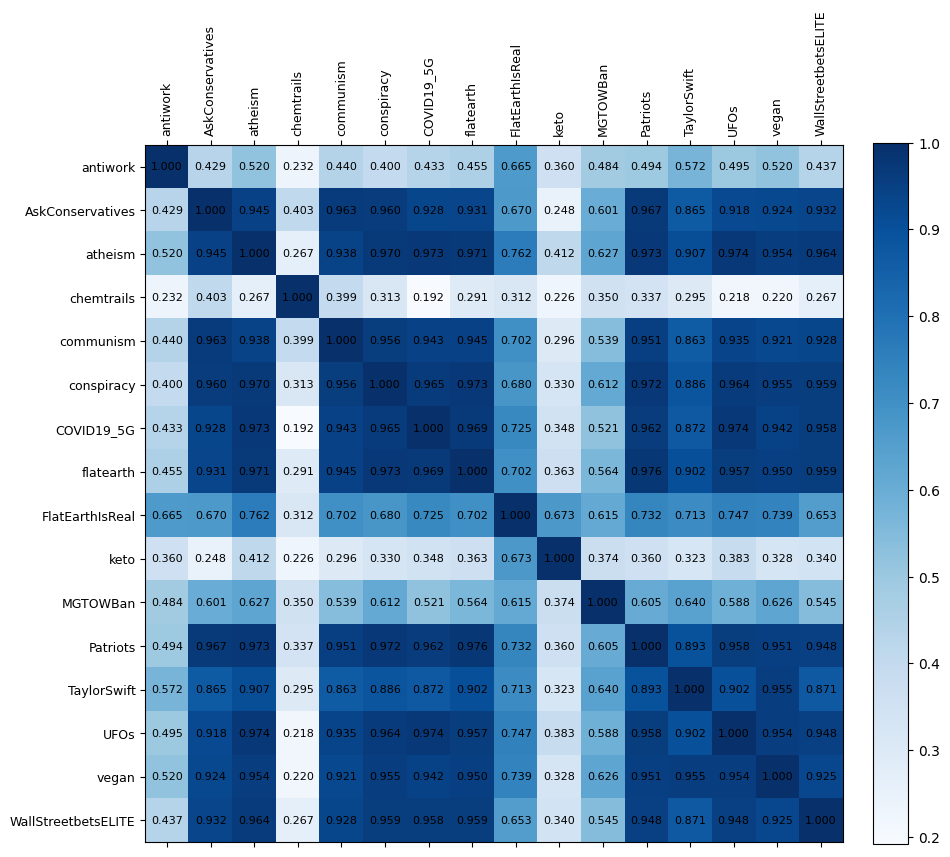

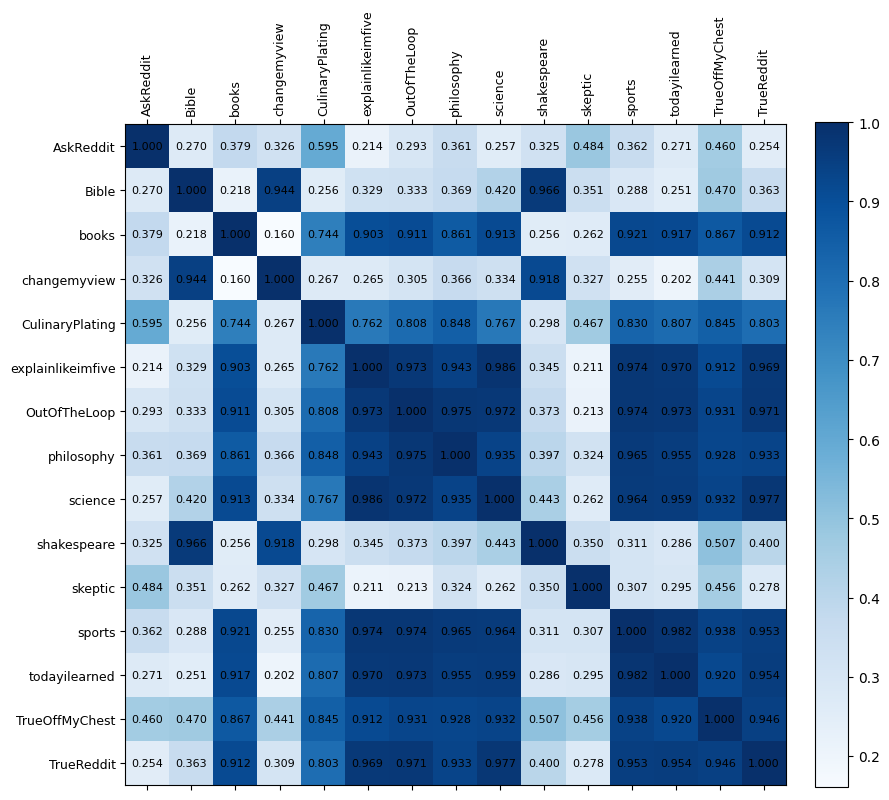

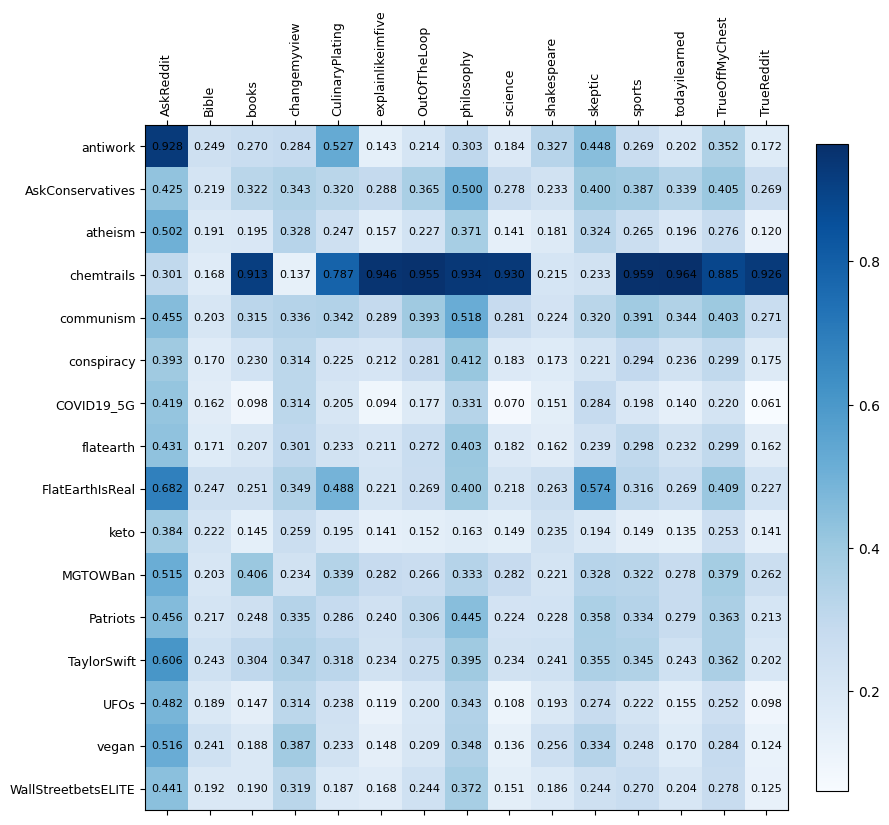

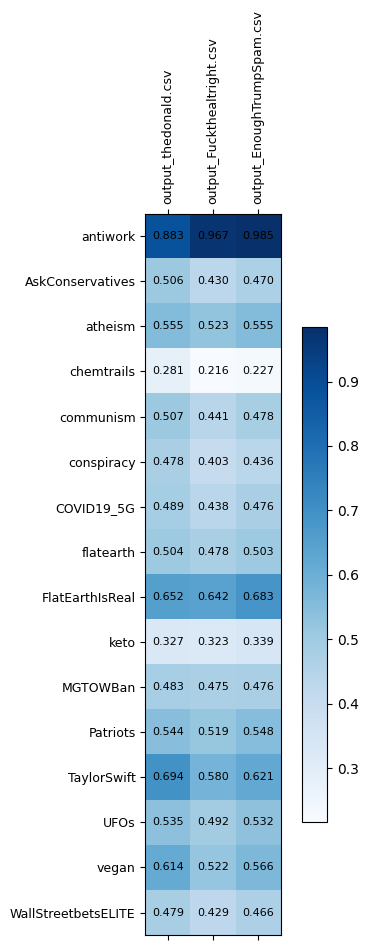

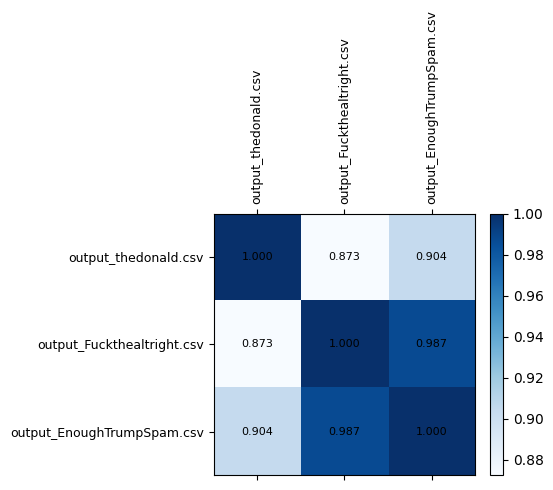

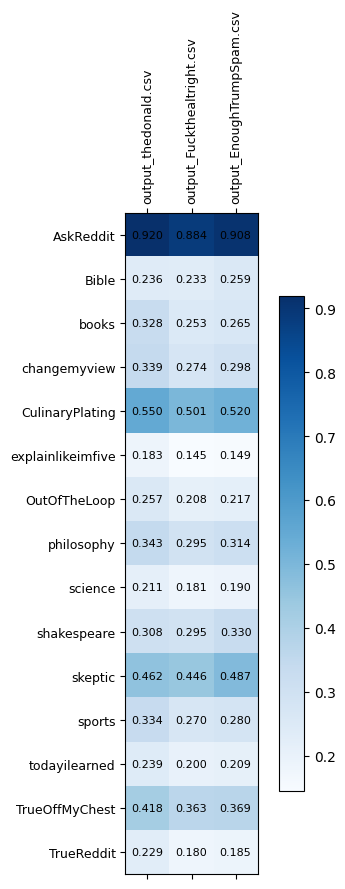

Average cosine similarity between conspiracy groups with 27 emotions: (np.float64(0.6875786974399388), 240, 256)
Average cosine similarity between conspiracy and not_conspiracy groups with 27 emotions: (np.float64(0.30116647017385056), 240, 240)
Average cosine similarity between not_conspiracy groups with 27 emotions: (np.float64(0.5979363585789479), 210, 225)


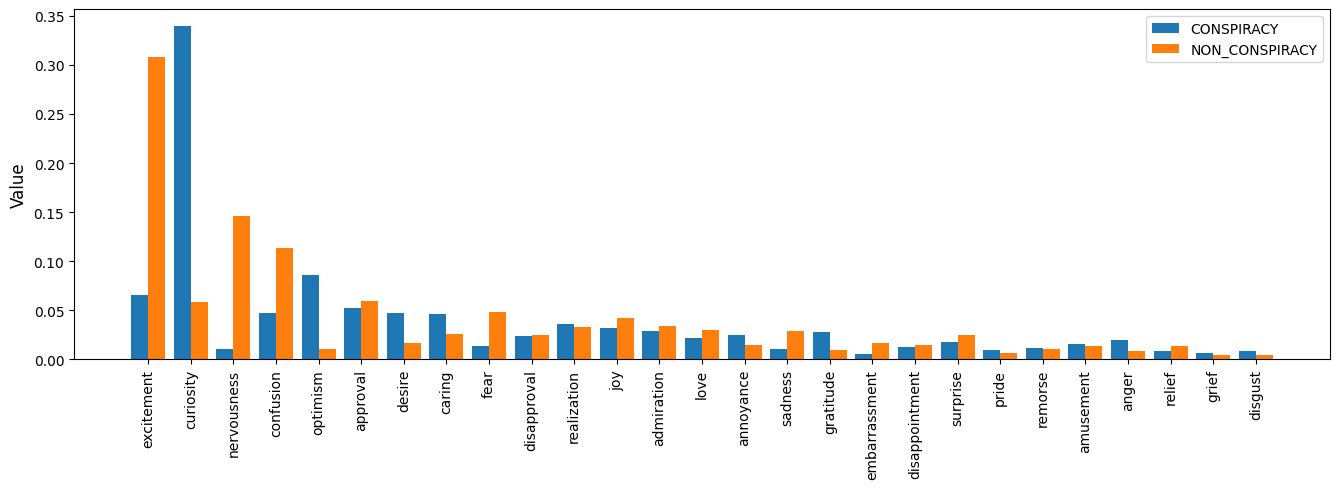

Grafico salvato in: plots/scatterplot_PCA_2D_27.png


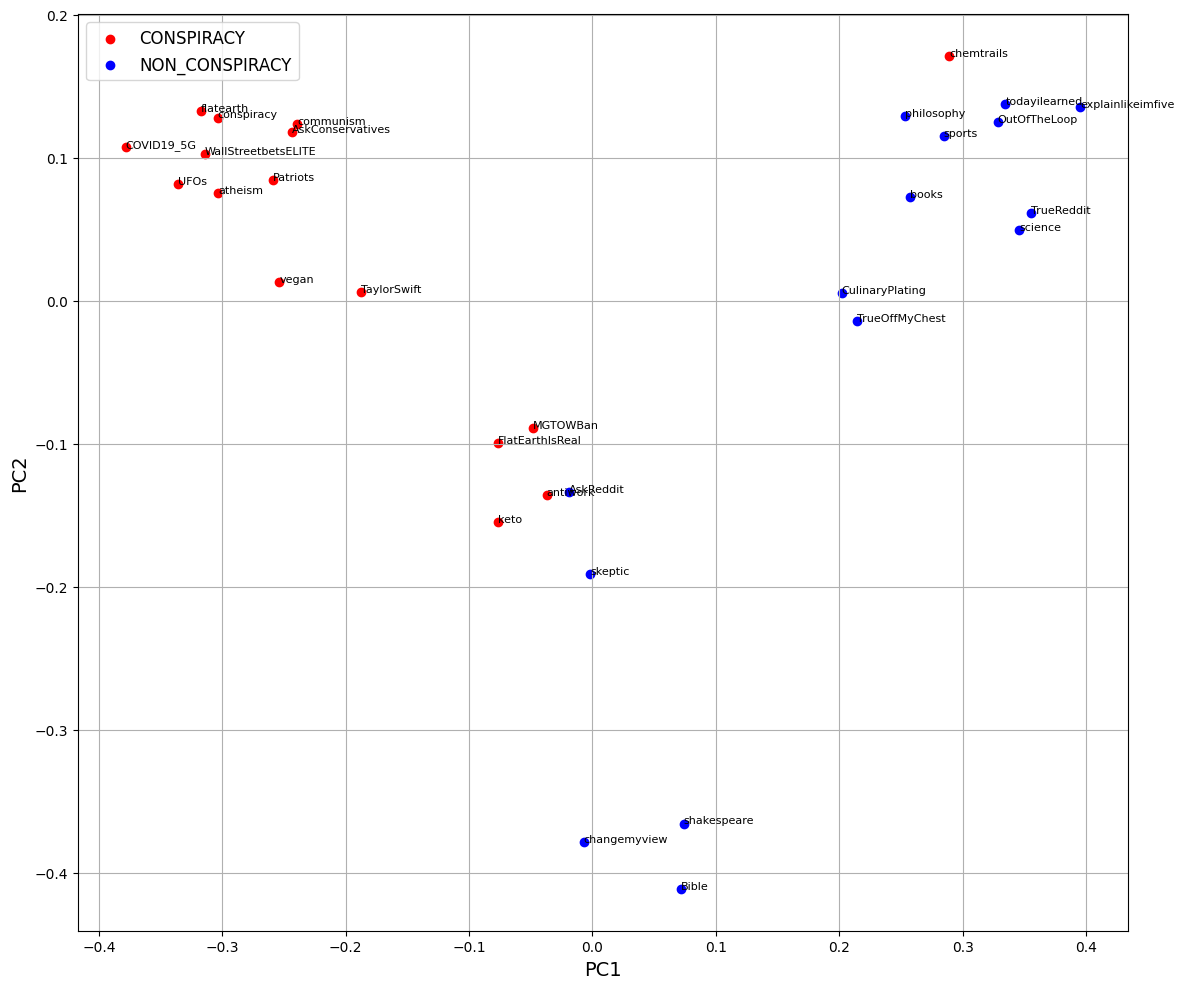

Grafico salvato in: plots/scatterplot_PCA_3D_27.png


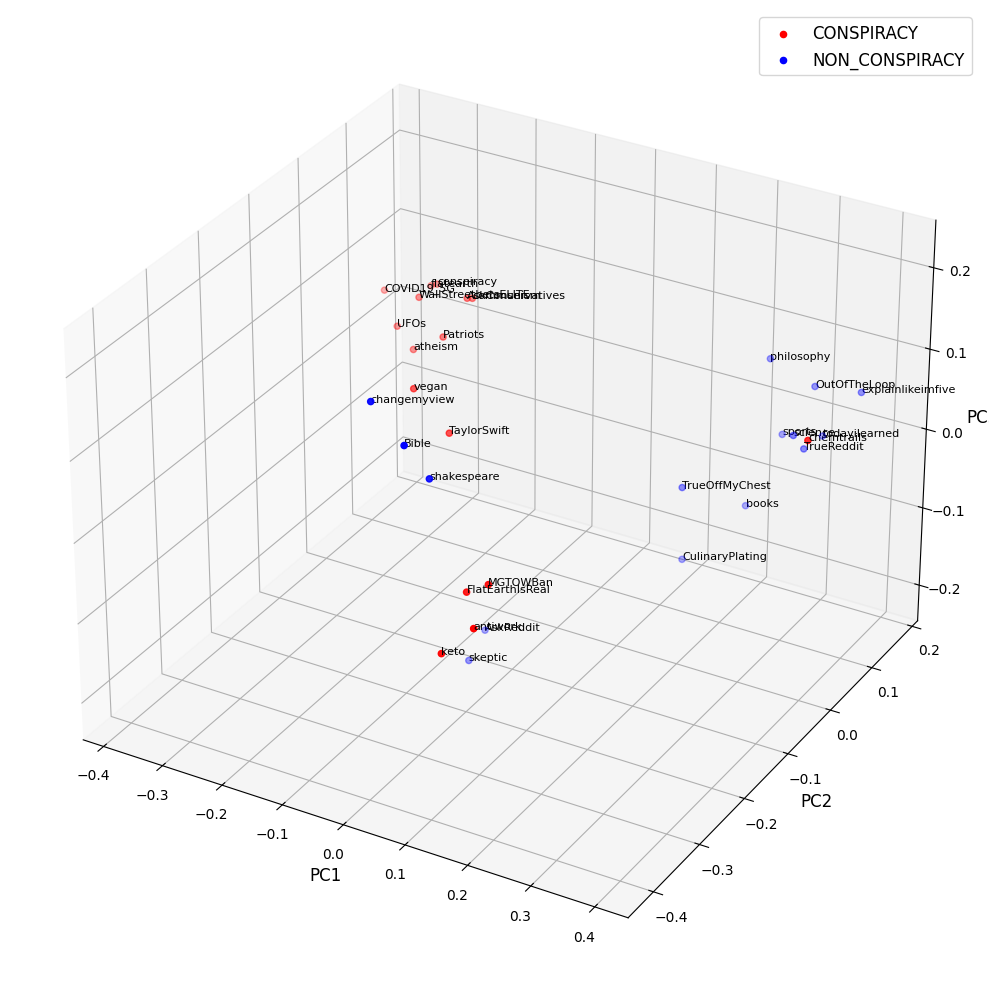

Grafico salvato in: plots/scatterplot_PCA_2D_27.png


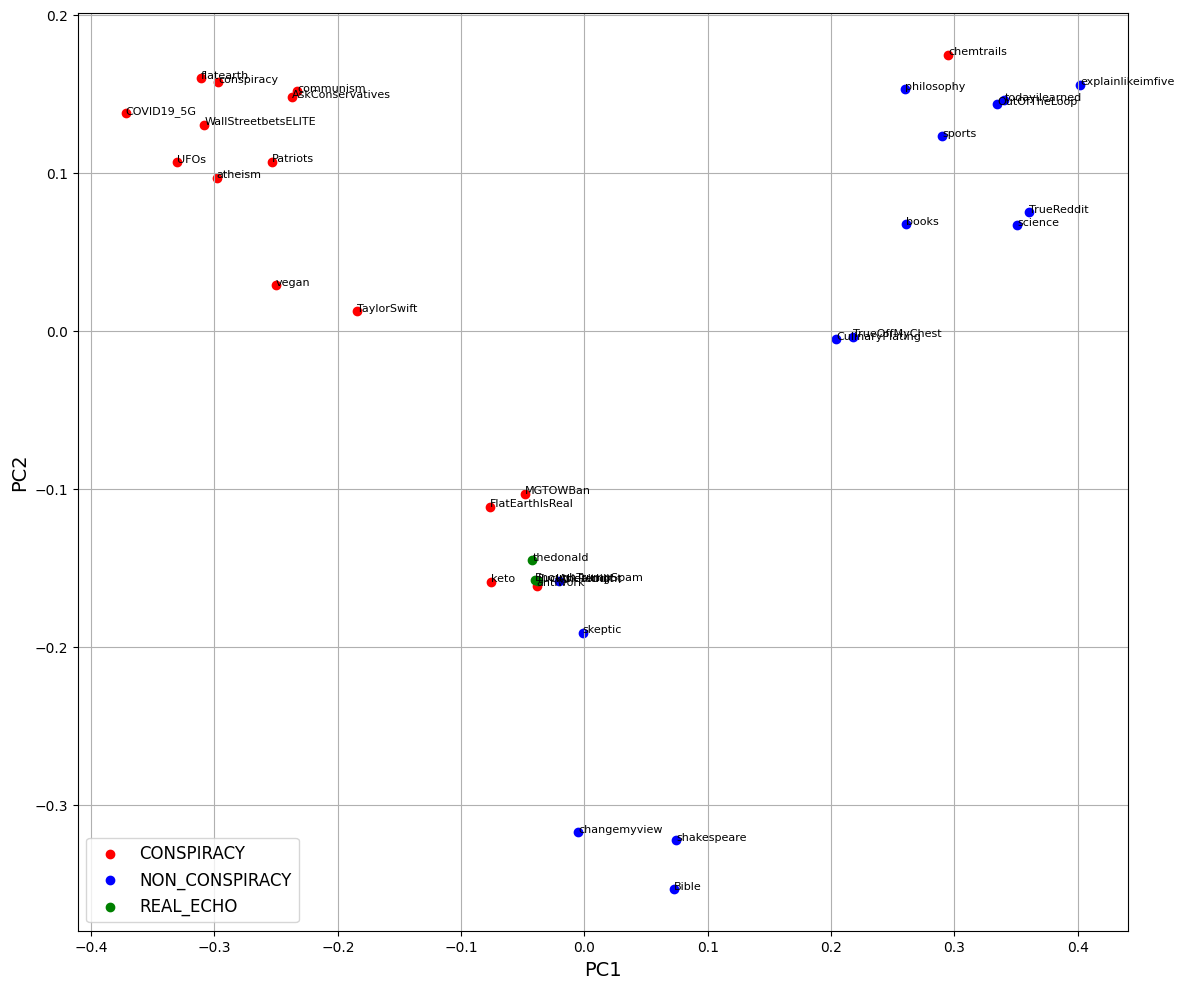

Grafico salvato in: plots/scatterplot_PCA_3D_27.png


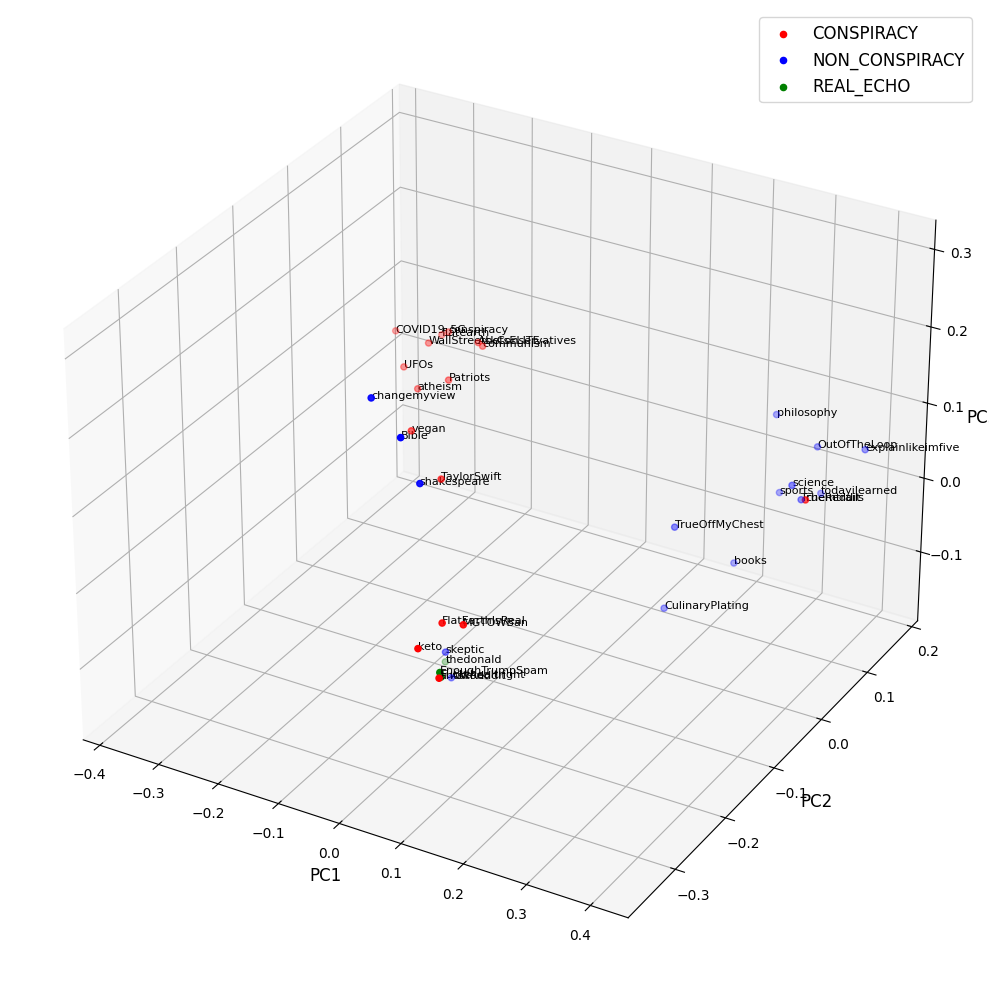

In [12]:
# -*- coding: utf-8 -*-

# ==== Import ====
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA


# ==== Utility ====

def ensure_dir(path):
    """Crea la cartella se non esiste."""
    os.makedirs(path, exist_ok=True)


# ==== Preprocessing e valutazione ====

def dataset_cleaner(controversial, non_controversial,
                    controversial_groups_to_use, non_controversial_groups_to_use):
    """
    - Filtra (se richiesto) per lista di file_name.
    - Drop colonne non numeriche note ("file_name", "neutral") per le fasi successive.
    Ritorna i due DataFrame puliti (copie).
    """
    controversial = controversial.copy()
    non_controversial = non_controversial.copy()

    if len(controversial_groups_to_use) != 0 and "file_name" in controversial.columns:
        controversial = controversial[controversial["file_name"].isin(controversial_groups_to_use)]

    if len(non_controversial_groups_to_use) != 0 and "file_name" in non_controversial.columns:
        non_controversial = non_controversial[non_controversial["file_name"].isin(non_controversial_groups_to_use)]

    # Manteniamo "file_name" per etichette su PCA, ma lo rimuoviamo prima dei calcoli numerici dove serve.
    # Qui restiamo coerenti con la tua logica originale:
    controversial = controversial.drop(columns=["file_name", "neutral"], errors='ignore')
    non_controversial = non_controversial.drop(columns=["file_name", "neutral"], errors='ignore')

    return controversial, non_controversial


def evaluate_best_emotions(controversial, non_controversial, num_emotions):
    """
    Seleziona le 'num_emotions' features con varianza più alta sull'unione dei due insiemi.
    """
    combo = pd.concat([controversial, non_controversial], axis=0)
    # Considera solo colonne numeriche
    combo_num = combo.select_dtypes(include=[np.number])
    return list(combo_num.var().sort_values(ascending=False).index[:num_emotions])


# ==== Similarità e matrici ====

def confusion_matrix_builder(df_a, df_b, emotions_to_use):
    """
    Calcola:
      - Similarità intra A (A vs A)
      - Similarità cross (A vs B)
      - Similarità intra B (B vs B)
    usando cosine_similarity sulle colonne emotions_to_use.
    """
    A = df_a[emotions_to_use].to_numpy()
    B = df_b[emotions_to_use].to_numpy()
    a_a = cosine_similarity(A, A)
    a_b = cosine_similarity(A, B)
    b_b = cosine_similarity(B, B)
    return a_a, a_b, b_b


def _safe_labels(desired_labels, fallback_count, prefix):
    """
    Se desired_labels è vuoto, genera nomi fittizi coerenti con i punti.
    Se la lista c'è ma non coincide in lunghezza, tronca o pad con nomi fittizi.
    """
    if desired_labels is None or len(desired_labels) == 0:
        return [f"{prefix}{i}" for i in range(fallback_count)]

    labels = list(desired_labels)
    if len(labels) < fallback_count:
        labels = labels + [f"{prefix}{i}" for i in range(len(labels), fallback_count)]
    elif len(labels) > fallback_count:
        labels = labels[:fallback_count]
    return labels


def plot_matrix(groups, name_to_use_x, name_to_use_y, type_of_groups, num_emotions):
    """
    Visualizza una matrice di similarità con etichette coerenti.
    name_to_use_x, name_to_use_y possono essere liste vuote -> verranno generati fallback.
    """
    ensure_dir("plots")

    n_rows, n_cols = groups.shape
    # Normalizza le liste di label
    labels_x = _safe_labels(name_to_use_x, n_cols, prefix="X")
    labels_y = _safe_labels(name_to_use_y, n_rows, prefix="Y")

    fig, ax = plt.subplots(figsize=(max(6, n_cols * 0.6), max(5, n_rows * 0.6)))
    cax = ax.matshow(groups)

    # Posizionamento tick coerente con le dimensioni della matrice
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(labels_x, rotation=90, fontsize=9)
    ax.set_yticklabels(labels_y, fontsize=9)

    # Valori numerici in cella
    for (i, j), z in np.ndenumerate(groups):
        ax.text(j, i, '{:0.3f}'.format(z), ha='center', va='center', fontsize=8)

    plt.set_cmap("Blues")
    fig.colorbar(cax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    out_path = f"plots/matrix_cosine_similarity_{type_of_groups}_{num_emotions}.png"
    fig.savefig(out_path, bbox_inches='tight', dpi=300)
    plt.show()


def avarage_confusion_matrix_similarity(matrix, is_square=False):
    """
    Ritorna (media_senza_diag, counter, totale_celle).
    Se is_square=True esclude la diagonale.
    """
    num_i, num_j = matrix.shape
    counter = 0
    somma = 0.0
    for i in range(num_i):
        for j in range(num_j):
            if is_square and i == j:
                continue
            somma += matrix[i, j]
            counter += 1
    return somma / counter if counter > 0 else np.nan, counter, num_i * num_j


def barplot_mean_emotions(controversial, non_controversial, best_emotions):
    """
    Barplot delle medie delle emozioni selezionate (CONSPIRACY vs NON_CONSPIRACY).
    controversial e non_controversial attesi come Series sulle 'best_emotions'.
    """
    ensure_dir("plots")
    X_axis = np.arange(len(best_emotions))

    plt.figure(figsize=(max(8, len(best_emotions) * 0.5), 5))
    plt.bar(X_axis - 0.2, controversial.values, 0.4, label="CONSPIRACY")
    plt.bar(X_axis + 0.2, non_controversial.values, 0.4, label="NON_CONSPIRACY")

    plt.xticks(X_axis, best_emotions, rotation='vertical', fontsize=10)
    plt.ylabel("Value", fontsize=12)
    plt.legend()
    out_path = f"plots/barplot_emotions_average_{len(best_emotions)}_emotions.png"
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches='tight', dpi=300)
    plt.show()


# ==== PCA ====

def perform_pca(data, n_components=None):
    """
    Applica la PCA dopo aver verificato che tutte le colonne siano numeriche.
    Ritorna (pca_results, explained_variance_ratio_).
    """
    if not all(data.dtypes.apply(lambda dtype: pd.api.types.is_numeric_dtype(dtype))):
        raise ValueError("Il dataset contiene colonne non numeriche. Verifica i dati.")

    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(data)
    explained_variance = pca.explained_variance_ratio_
    return pca_results, explained_variance


def _extract_labels_for_scatter(df_list):
    """
    Prende una lista di DataFrame e costruisce:
      - una Series 'labels' con i nomi (file_name se presente, altrimenti indice)
      - una Series 'sources' con la sorgente (già impostata in ciascun DF)
    Restituisce labels, sources e un DataFrame numerico pronto per la PCA.
    """
    # Concateniamo mantenendo file_name e source se presenti
    combined = pd.concat(df_list, ignore_index=True)

    # Etichette per i punti
    if "file_name" in combined.columns:
        labels = combined["file_name"].astype(str)
    else:
        labels = pd.Series(combined.index.astype(str), name="label")

    # Sorgenti per colori
    if "source" not in combined.columns:
        raise ValueError("Manca la colonna 'source' necessaria per colorare i punti.")

    sources = combined["source"].astype(str)

    # Drop colonne non numeriche
    data_numeric = combined.drop(columns=['file_name', 'source'], errors='ignore')
    data_numeric = data_numeric.select_dtypes(include=[np.number])

    return labels, sources, data_numeric


def plot_pca_combined(plot_type, controversial, non_controversial, num_emotions):
    """
    PCA 2D/3D con etichette sui punti per CONSPIRACY e NON_CONSPIRACY.
    Usa 'file_name' se presente come label; altrimenti indice.
    """
    ensure_dir("plots")

    # Creiamo copie per evitare side effect
    c_df = controversial.copy()
    n_df = non_controversial.copy()
    c_df["source"] = "CONSPIRACY"
    n_df["source"] = "NON_CONSPIRACY"

    labels, sources, data_for_pca = _extract_labels_for_scatter([c_df, n_df])

    # PCA
    pca_results, explained_variance = perform_pca(data_for_pca)

    timestamp = datetime.now().strftime("%d%m%y_%H%M")

    # Palette semplice
    colors_map = {
        'CONSPIRACY': 'red',
        'NON_CONSPIRACY': 'blue'
    }

    if plot_type == "2D":
        plt.figure(figsize=(12, 10))
        for label in sources.unique():
            mask = (sources == label).to_numpy()
            plt.scatter(pca_results[mask, 0], pca_results[mask, 1],
                        c=colors_map.get(label, 'gray'), label=label)

            # Aggiungi etichette
            idxs = np.where(mask)[0]
            for i in idxs:
                plt.text(pca_results[i, 0], pca_results[i, 1],
                         str(labels.iloc[i]), fontsize=8)

        plt.xlabel('PC1', fontsize=14)
        plt.ylabel('PC2', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True)
        out_file = f"plots/scatterplot_PCA_2D_{num_emotions}.png"
        plt.tight_layout()
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {out_file}")
        plt.show()

    elif plot_type == "3D":
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        for label in sources.unique():
            mask = (sources == label).to_numpy()
            ax.scatter(pca_results[mask, 0], pca_results[mask, 1], pca_results[mask, 2],
                       c=colors_map.get(label, 'gray'), label=label)

            idxs = np.where(mask)[0]
            for i in idxs:
                ax.text(pca_results[i, 0], pca_results[i, 1], pca_results[i, 2],
                        str(labels.iloc[i]), fontsize=8)

        ax.set_xlabel('PC1', fontsize=12)
        ax.set_ylabel('PC2', fontsize=12)
        ax.set_zlabel('PC3', fontsize=12)
        ax.legend(fontsize=12)
        ax.grid(True)
        out_file = f"plots/scatterplot_PCA_3D_{num_emotions}.png"
        plt.tight_layout()
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {out_file}")
        plt.show()

    else:
        raise ValueError("Il tipo di plot deve essere '2D' o '3D'")


def plot_pca_combined_with_real(plot_type, controversial, non_controversial, real, num_emotions):
    """
    PCA 2D/3D con etichette sui punti per CONSPIRACY, NON_CONSPIRACY e REAL_ECHO.
    """
    ensure_dir("plots")

    c_df = controversial.copy()
    n_df = non_controversial.copy()
    r_df = real.copy()

    c_df["source"] = "CONSPIRACY"
    n_df["source"] = "NON_CONSPIRACY"
    r_df["source"] = "REAL_ECHO"

    labels, sources, data_for_pca = _extract_labels_for_scatter([c_df, n_df, r_df])

    pca_results, explained_variance = perform_pca(data_for_pca)

    colors_map = {
        'CONSPIRACY': 'red',
        'NON_CONSPIRACY': 'blue',
        'REAL_ECHO': 'green'
    }

    if plot_type == "2D":
        plt.figure(figsize=(12, 10))
        for label in sources.unique():
            mask = (sources == label).to_numpy()
            plt.scatter(pca_results[mask, 0], pca_results[mask, 1],
                        c=colors_map.get(label, 'gray'), label=label)

            idxs = np.where(mask)[0]
            for i in idxs:
                plt.text(pca_results[i, 0], pca_results[i, 1],
                         str(labels.iloc[i]), fontsize=8)

        plt.xlabel('PC1', fontsize=14)
        plt.ylabel('PC2', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True)
        out_file = f"plots/scatterplot_PCA_2D_{num_emotions}.png"
        plt.tight_layout()
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {out_file}")
        plt.show()

    elif plot_type == "3D":
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        for label in sources.unique():
            mask = (sources == label).to_numpy()
            ax.scatter(pca_results[mask, 0], pca_results[mask, 1], pca_results[mask, 2],
                       c=colors_map.get(label, 'gray'), label=label)

            idxs = np.where(mask)[0]
            for i in idxs:
                ax.text(pca_results[i, 0], pca_results[i, 1], pca_results[i, 2],
                        str(labels.iloc[i]), fontsize=8)

        ax.set_xlabel('PC1', fontsize=12)
        ax.set_ylabel('PC2', fontsize=12)
        ax.set_zlabel('PC3', fontsize=12)
        ax.legend(fontsize=12)
        ax.grid(True)
        out_file = f"plots/scatterplot_PCA_3D_{num_emotions}.png"
        plt.tight_layout()
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {out_file}")
        plt.show()

    else:
        raise ValueError("Il tipo di plot deve essere '2D' o '3D'")



controversial_groups_to_use = []
non_controversial_groups_to_use = []

num_emotions_list = [27]  # lista così puoi iterare su più valori

ensure_dir("plots")

for x in num_emotions_list:

    # Ricarico fresh per ogni iterazione
    controversial = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv")
    non_controversial = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv")[controversial.columns]
    real_echo = pd.read_csv("OLD/DataSet/3.outputs_Emotions/mean_vector_real_echo.csv")[controversial.columns]

    for df in [controversial, non_controversial, real_echo]:
        if "file_name" in df.columns:
            df["file_name"] = df["file_name"].str.replace("^output_", "", regex=True)
            df["file_name"] = df["file_name"].str.replace(".csv", "", regex=True)



    # Salvo labels prima del drop per le matrici (se servono)
    cont_names = controversial["file_name"].tolist() if "file_name" in controversial.columns else []
    non_cont_names = non_controversial["file_name"].tolist() if "file_name" in non_controversial.columns else []
    real_names = real_echo["file_name"].tolist() if "file_name" in real_echo.columns else []

    controversial_clean, non_controversial_clean = dataset_cleaner(
        controversial, non_controversial, controversial_groups_to_use, non_controversial_groups_to_use
    )
    # Per 'real_echo' manteniamo coerenza con pulizia
    real_echo_clean = real_echo.drop(columns=["file_name", "neutral"], errors='ignore')

    # Selezione migliori emozioni
    best_emotions = evaluate_best_emotions(controversial_clean, non_controversial_clean, x)
    print(f"Best emotions ({x}): {best_emotions}")

    # Filtra i DF sulle best_emotions
    controversial_fe = controversial_clean[best_emotions]
    non_controversial_fe = non_controversial_clean[best_emotions]
    real_echo_fe = real_echo_clean[best_emotions]

    # Matrici di similarità
    c_c, c_nc, nc_nc = confusion_matrix_builder(controversial_fe, non_controversial_fe, best_emotions)
    c_r, c_r_cross, r_r = confusion_matrix_builder(controversial_fe, real_echo_fe, best_emotions)
    # Nota: 'confusion_matrix_builder' ritorna (A-A, A-B, B-B):
    # qui c_r = C-C (uguale a c_c), c_r_cross = C-R, r_r = R-R
    # Per la parte NON_CONSPIRACY vs REAL:
    nc_r_dummy, nc_r, r_r2 = confusion_matrix_builder(non_controversial_fe, real_echo_fe, best_emotions)
    # dove nc_r è N-R

    # Etichette per plot delle matrici
    # Se le liste di "to_use" sono vuote, uso i nomi effettivi caricati dal file (o fallback)
    cont_labels = controversial_groups_to_use if len(controversial_groups_to_use) > 0 else cont_names
    non_cont_labels = non_controversial_groups_to_use if len(non_controversial_groups_to_use) > 0 else non_cont_names
    real_labels = real_echo_groups_to_use if len(real_echo_groups_to_use) > 0 else real_names

    # Plot matrici
    plot_matrix(c_c, cont_labels, cont_labels, "conspiracy", x)
    plot_matrix(nc_nc, non_cont_labels, non_cont_labels, "not_conspiracy", x)
    plot_matrix(c_nc, non_cont_labels, cont_labels, "conspiracy-not_conspiracy", x)

    plot_matrix(c_r_cross, real_labels, cont_labels, "conspiracy-realEcho", x)
    plot_matrix(r_r, real_labels, real_labels, "realEcho", x)
    plot_matrix(nc_r, real_labels, non_cont_labels, "non_conspiracy-realEcho", x)

    # Statistiche
    print("Average cosine similarity between conspiracy groups "
          f"with {x} emotions: {avarage_confusion_matrix_similarity(c_c, is_square=True)}")
    print("Average cosine similarity between conspiracy and not_conspiracy groups "
          f"with {x} emotions: {avarage_confusion_matrix_similarity(c_nc, is_square=False)}")
    print("Average cosine similarity between not_conspiracy groups "
          f"with {x} emotions: {avarage_confusion_matrix_similarity(nc_nc, is_square=True)}")

    # Barplot medie emozioni
    barplot_mean_emotions(controversial_fe.mean(), non_controversial_fe.mean(), best_emotions)

    # PCA con etichette
    # Per le PCA vogliamo conservare eventualmente 'file_name' per le etichette,
    # quindi ricostruiamo DF con file_name se presente.
    # Riprendiamo i DF originali, ma filtriamo le colonne alle sole best_emotions (+ file_name se esiste)
    def rebuild_with_labels(original_df, cols):
        keep_cols = cols.copy()
        if "file_name" in original_df.columns:
            keep_cols = (["file_name"] + cols)
        df = original_df[keep_cols].copy()
        return df

    controversial_for_pca = rebuild_with_labels(controversial,
                                                best_emotions)
    non_controversial_for_pca = rebuild_with_labels(non_controversial[controversial.columns],
        best_emotions
    )
    real_echo_for_pca = rebuild_with_labels(real_echo[controversial.columns],
        best_emotions
    )

    # Plot PCA 2D/3D (solo C vs NC)
    plot_pca_combined("2D", controversial_for_pca, non_controversial_for_pca, x)
    plot_pca_combined("3D", controversial_for_pca, non_controversial_for_pca, x)

    # Plot PCA 2D/3D (C vs NC vs REAL)
    plot_pca_combined_with_real("2D", controversial_for_pca, non_controversial_for_pca, real_echo_for_pca, x)
    plot_pca_combined_with_real("3D", controversial_for_pca, non_controversial_for_pca, real_echo_for_pca, x)


In [11]:
from huggingface_hub import snapshot_download
#snapshot_download(repo_id="lzw1008/ConspEmoLLM-v2", local_dir="./ConspEmoLLM-v2")
snapshot_download(repo_id="lzw1008/ConspEmoLLM-7b", local_dir="./ConspEmoLLM-7b")

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/3.59G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [4]:
# Requisiti:
# pip install -U torch transformers accelerate

import re, math, torch
from torch.nn.functional import log_softmax
from transformers import AutoTokenizer, AutoModelForCausalLM

# === Config ===
MODEL_ID = "./ConspEmoLLM-v2"       # oppure "lzw1008/ConspEmoLLM-7b"
_DEVICE = torch.device("cpu")        # CPU = stabile. Metti "mps" se vuoi provare su Mac
_DTYPE = torch.float32
_MAX_CHARS = 600
_MAX_TOKENS = 512

_tokenizer = None
_model = None

def _load_once():
    global _tokenizer, _model
    if _tokenizer is not None and _model is not None:
        return
    _tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if _tokenizer.pad_token_id is None:
        _tokenizer.pad_token = _tokenizer.eos_token
    _model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=_DTYPE,
        attn_implementation="eager",
        use_safetensors=True
    ).to(_DEVICE).eval()

def _score_candidate(prompt_ids: torch.Tensor, cand_ids: torch.Tensor) -> float:
    """
    Somma delle log-prob dei token di 'cand_ids' condizionati al prompt.
    CORRETTO: usa cand_ids[:, :-1] (sequenza), NON cand_ids[:-1] (batch).
    """
    with torch.inference_mode():
        if cand_ids.size(1) > 1:
            # prompt + tutti i token della candidata tranne l'ultimo (dimensione sequenza)
            inp_ids = torch.cat([prompt_ids, cand_ids[:, :-1]], dim=1)
        else:
            inp_ids = prompt_ids
        out = _model(input_ids=inp_ids, use_cache=False)
        # prendiamo le ultime posizioni pari alla lunghezza della candidata
        L = cand_ids.size(1)
        logits = out.logits[:, -L:, :]                  # [1, L, V]
        logprobs = log_softmax(logits, dim=-1)          # [1, L, V]
        # raccogli le logprob dei token della candidata
        gather_idx = cand_ids.view(1, L, 1)             # [1, L, 1]
        token_logps = logprobs.gather(-1, gather_idx).squeeze(-1)  # [1, L]
        return float(token_logps.sum().item())

def predict_conspiracy_proba(text: str) -> float:
    """
    Restituisce P(Conspiracy) in [0,1], confrontando le due risposte candidate "0" e "1".
    """
    _load_once()

    SYSTEM_TASK = (
        "Classify the text regarding possible conspiracy theories into one of the following two classes: "
        "0. Non-Conspiracy. 1. Conspiracy. Answer with a single digit (0 or 1) only."
    )
    text = re.sub(r"\s+", " ", str(text)).strip()
    if len(text) > _MAX_CHARS:
        text = text[:_MAX_CHARS] + " ..."

    prompt = (
        "Human:\n"
        f"Task: {SYSTEM_TASK}\n"
        f"Text: {text}\n"
        "Class:\n"
        "Assistant:"    # <-- nessuno spazio dopo i due punti
    )

    enc = _tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=_MAX_TOKENS, padding=False
    )
    prompt_ids = enc["input_ids"].to(_DEVICE)

    # Candidati come SEQUENZE (batch=1, seq_len=numero di token)
    ids0 = _tokenizer.encode("0", add_special_tokens=False)
    ids1 = _tokenizer.encode("1", add_special_tokens=False)
    if len(ids0) == 0 or len(ids1) == 0:
        return 0.0  # fallback prudente

    cand0_ids = torch.tensor([ids0], device=_DEVICE, dtype=prompt_ids.dtype)
    cand1_ids = torch.tensor([ids1], device=_DEVICE, dtype=prompt_ids.dtype)

    s0 = _score_candidate(prompt_ids, cand0_ids)
    s1 = _score_candidate(prompt_ids, cand1_ids)

    # Softmax a 2 vie stabile numericamente: p1 = exp(s1) / (exp(s0)+exp(s1))
    m = max(s0, s1)
    p1 = math.exp(s1 - m) / (math.exp(s0 - m) + math.exp(s1 - m))
    return float(p1)

# --- Esempio ---

#tests = [
#    "5G towers caused the pandemic and governments are hiding it.",
#    "The sky is blue and water boils at 100C.",
#    "They say the election was stolen by a global cabal.",
#]
#for t in tests:
#    print(f"{predict_conspiracy_proba(t):.3f}  <- {t}")


In [8]:
from pathlib import Path
import pandas as pd

folder_echo = Path("Delivery/1_Non_Filtered_Data/echo_data")
files_echo = sorted(folder_echo.glob("*.csv"))

csv_to_analyze = [
     "Delivery/1_Non_Filtered_Data/echo_data/reddit_data_COVID19_5G.csv","Delivery/1_Non_Filtered_Data/echo_data/reddit_data_flatearth.csv","Delivery/1_Non_Filtered_Data/echo_data/reddit_data_conspiracy.csv", "Delivery/1_Non_Filtered_Data/echo_data/reddit_data_chemtrails.csv"
]


true_conspiracy = 0
false_nonconspiracy = 0
dfs = []
for f in csv_to_analyze:
    df = pd.read_csv(f, sep=None, engine="python")
    text = df["body"].astype(str).head(10).str.cat(sep=" ")
    predict = predict_conspiracy_proba(text)
    print(f"sub-reddit:{f} - > {predict}")
    if predict >= 0.5:
        true_conspiracy += 1
    else:
        false_nonconspiracy += 1


KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import pandas as pd

folder_nonecho = Path("Delivery/1_Non_Filtered_Data/non_echo_data")
files_nonecho = sorted(folder_nonecho.glob("*.csv"))

true_nonconspiracy = 0
false_conspiracy = 0
dfs = []
for f in files_nonecho:
    df = pd.read_csv(f, sep=None, engine="python")
    text = df["body"].astype(str).head(100).str.cat(sep=" ")
    predict = predict_conspiracy_proba(text)
    print(f"sub-reddit:{f} - > {predict}")
    if predict >= 0.5:
        false_conspiracy += 1
    else:
        true_nonconspiracy += 1

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_AskReddit.csv - > 0.0003006502814586352
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_Bible.csv - > 8.438375381687866e-05
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_CulinaryPlating.csv - > 0.0031216895311172057
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_OutOfTheLoop.csv - > 0.044578877817742925
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_TrueOffMyChest.csv - > 0.002814272262731374
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_TrueReddit.csv - > 7.916370040829042e-05
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_books.csv - > 0.004783682445396917
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_changemyview.csv - > 0.05370156466482531
sub-reddit:Delivery/1_Non_Filtered_Data/non_echo_data/reddit_data_explainlikeimfive.csv - > 0.0005487574075370073
sub-reddit:Delivery/1_Non_Filtere

3 TOPIC CONSPIRACY e 3 NO, su SINGOLE FRASI

In [5]:
from pathlib import Path
import pandas as pd

csv_to_analyze = ["Delivery/1_Non_Filtered_Data/echo_data/reddit_data_COVID19_5G.csv","Delivery/1_Non_Filtered_Data/echo_data/reddit_data_flatearth.csv","Delivery/1_Non_Filtered_Data/echo_data/reddit_data_UFOs.csv"]
files_echo = sorted(folder_echo.glob("*.csv"))


dfs = []
for f in csv_to_analyze:
    df = pd.read_csv(f, sep=None, engine="python")
    elements = df["body"].astype(str).head(10)
    current_conspiracy_percentage = 0
    for e in elements:
        current_conspiracy_percentage += predict_conspiracy_proba(e)
        print(f"---------------{current_conspiracy_percentage}")

    print(f"sub-reddit:{f} - > {current_conspiracy_percentage/len(elements)}")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

---------------0.18901680267294813
---------------0.19808220511422575
---------------0.21933266691516037
---------------0.2203550191135851
---------------0.2210701221302002
---------------0.685205954027253
---------------0.685311737265871
---------------0.9484711502215176
---------------0.9534183878563068
---------------0.9540923306438994
sub-reddit:Delivery/1_Non_Filtered_Data/echo_data/reddit_data_COVID19_5G.csv - > 0.09540923306438995
---------------0.004204548501598952
---------------0.627313136628024
---------------0.663829711412804
---------------0.7162435724105991
---------------0.7292775993892721
---------------0.8570664450906383
---------------0.866131847531916
---------------1.0795576912944156
---------------1.0874372457229038
---------------1.0975066349051066
sub-reddit:Delivery/1_Non_Filtered_Data/echo_data/reddit_data_flatearth.csv - > 0.10975066349051066


FileNotFoundError: [Errno 2] No such file or directory: 'Delivery/1_Non_Filtered_Data/echo_data/reddit_data_UFO.csv'

In [4]:
# Requisiti:
# pip install -U torch transformers accelerate

import re, math, torch
from torch.nn.functional import log_softmax
from transformers import AutoTokenizer, AutoModelForCausalLM

# === Config ===
MODEL_ID   = "./ConspEmoLLM-v2"        # oppure "lzw1008/ConspEmoLLM-7b"
_DEVICE    = torch.device("cpu")        # CPU = stabile. Metti "mps" se vuoi provare su Mac
_DTYPE     = torch.float32
_MAX_CHARS = 600
_MAX_TOKENS = 256

_tok = None
_model = None

def _load_once():
    global _tok, _model
    if _tok is not None and _model is not None:
        return
    _tok = AutoTokenizer.from_pretrained(MODEL_ID)
    if _tok.pad_token_id is None:
        _tok.pad_token = _tok.eos_token
    _model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=_DTYPE,
        attn_implementation="eager",
        use_safetensors=True
    ).to(_DEVICE).eval()

def _score_seq(prompt_ids: torch.Tensor, cand_ids: torch.Tensor) -> float:
    """
    Somma delle log-prob dei token della sequenza candidata condizionati a:
    [prompt] + cand[:-1]  -> predice cand[0..L-1] uno per volta.
    """
    L = cand_ids.size(1)
    with torch.inference_mode():
        if L > 1:
            inp_ids = torch.cat([prompt_ids, cand_ids[:, :-1]], dim=1)
        else:
            inp_ids = prompt_ids
        out = _model(input_ids=inp_ids, use_cache=False)
        logits = out.logits[:, -L:, :]       # [1, L, V]
        logprobs = log_softmax(logits, dim=-1)
        gather_idx = cand_ids.view(1, L, 1)  # [1, L, 1]
        token_logps = logprobs.gather(-1, gather_idx).squeeze(-1)  # [1, L]
        return float(token_logps.sum().item())

def _softmax3(s0, s1, s2):
    m = max(s0, s1, s2)
    e0, e1, e2 = math.exp(s0 - m), math.exp(s1 - m), math.exp(s2 - m)
    Z = e0 + e1 + e2
    return e0 / Z, e1 / Z, e2 / Z

def predict_task3_proba(text: str, specific_conspiracy: str):
    """
    Task 3:
    Classify into {0: Unrelated, 1: Related (not supporting), 2: Conspiracy}.
    Ritorna: {'probs': {'0': p0, '1': p1, '2': p2}, 'label': int}
    """
    _load_once()

    # Prompt "chiuso" (niente spazio dopo Assistant:)
    task = (f"Classify the text regarding the specific category [{specific_conspiracy}] into one of the "
            "following three classes: 0. Unrelated. 1. Related (but not supporting). "
            "2. Conspiracy (related and supporting). Answer with a single digit (0 or 1 or 2) only.")
    text = re.sub(r"\s+", " ", str(text)).strip()
    if len(text) > _MAX_CHARS:
        text = text[:_MAX_CHARS] + " ..."

    prompt = (
        "Human:\n"
        f"Task: {task}\n"
        f"Text: {text}\n"
        "Class:\n"
        "Assistant:"
    )

    enc = _tok(prompt, return_tensors="pt", truncation=True, max_length=_MAX_TOKENS, padding=False)
    prompt_ids = enc["input_ids"].to(_DEVICE)

    # Costruisci le sequenze candidate in modo robusto:
    # prova prima " 0"/" 1"/" 2" (con spazio), se il tokenizer non le ha come singolo token
    # usa il fallback senza spazio; in ogni caso usiamo TUTTA la sequenza risultante.
    def enc_cand(s):
        ids = _tok.encode(s, add_special_tokens=False)
        if not ids:
            ids = _tok.encode(s.strip(), add_special_tokens=False)
        return torch.tensor([ids], device=_DEVICE, dtype=prompt_ids.dtype)

    cand0 = enc_cand(" 0") if _tok.encode(" 0", add_special_tokens=False) else enc_cand("0")
    cand1 = enc_cand(" 1") if _tok.encode(" 1", add_special_tokens=False) else enc_cand("1")
    cand2 = enc_cand(" 2") if _tok.encode(" 2", add_special_tokens=False) else enc_cand("2")

    # Se qualcosa è ancora vuoto, fallback prudente
    if cand0.numel() == 0 or cand1.numel() == 0 or cand2.numel() == 0:
        return {'probs': {'0': 1/3, '1': 1/3, '2': 1/3}, 'label': 0}

    s0 = _score_seq(prompt_ids, cand0)
    s1 = _score_seq(prompt_ids, cand1)
    s2 = _score_seq(prompt_ids, cand2)

    p0, p1, p2 = _softmax3(s0, s1, s2)
    label = int(max([(0, p0), (1, p1), (2, p2)], key=lambda x: x[1])[0])
    return {'probs': {'0': p0, '1': p1, '2': p2}, 'label': label}

"""
# --- Esempio ---
if __name__ == "__main__":
    samples = [
        ("5G towers caused the pandemic and governments are hiding it.", "5G"),
        ("Discussion about ballot printing, counting, and monitoring logistics.", "Election fraud"),
        ("The sky is blue. Nothing to do with conspiracies.", "Chemtrails"),
    ]
    for txt, cat in samples:
        out = predict_task3_proba(txt, cat)
        print(f"[{cat}] {out['probs']} -> label={out['label']}")
"""


'\n# --- Esempio ---\nif __name__ == "__main__":\n    samples = [\n        ("5G towers caused the pandemic and governments are hiding it.", "5G"),\n        ("Discussion about ballot printing, counting, and monitoring logistics.", "Election fraud"),\n        ("The sky is blue. Nothing to do with conspiracies.", "Chemtrails"),\n    ]\n    for txt, cat in samples:\n        out = predict_task3_proba(txt, cat)\n        print(f"[{cat}] {out[\'probs\']} -> label={out[\'label\']}")\n'

In [5]:
from pathlib import Path
import pandas as pd

print("Non Conspiracy Starting")
folder = Path("Delivery/1_Non_Filtered_Data/non_echo_data")
files = sorted(folder.glob("*.csv"))
for f in files:
    df = pd.read_csv(f, sep=None, engine="python")
    text = df["body"].astype(str).head(10).str.cat(sep=" ")
    cat = str(f).split("_")[len(str(f).split("_")) - 1].replace(".csv", " ")
    predict = predict_task3_proba(text,cat)
    print(f"sub-reddit:{cat} - > {predict}")

print("Conspiracy Starting")
folder = Path("Delivery/1_Non_Filtered_Data/echo_data")
files = sorted(folder.glob("*.csv"))

for f in files:
    df = pd.read_csv(f, sep=None, engine="python")
    text = df["body"].astype(str).head(10).str.cat(sep=" ")
    cat = str(f).split("_")[len(str(f).split("_")) - 1].replace(".csv", " ")
    print(cat)
    predict = predict_task3_proba(text,cat)
    print(f"sub-reddit:{cat} - > {predict}")





Non Conspiracy Starting


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

sub-reddit:skeptic  - > {'probs': {'0': 0.6568832430559837, '1': 0.021433745647639665, '2': 0.3216830112963766}, 'label': 0}
sub-reddit:sports  - > {'probs': {'0': 0.9849159461377945, '1': 0.00030799042686023657, '2': 0.014776063435345089}, 'label': 0}
sub-reddit:stanford  - > {'probs': {'0': 0.9830590428729791, '1': 0.0019543853203391986, '2': 0.014986571806681741}, 'label': 0}
sub-reddit:todayilearned  - > {'probs': {'0': 0.9560705533498962, '1': 0.02954017985916326, '2': 0.014389266790940556}, 'label': 0}
Conspiracy Starting
AskConservatives 


KeyboardInterrupt: 